# NLP and Baseline Modeling - Triagegeist - MIMIC-IV-ED - FULL DATASET

from https://physionet.org/content/mimic-iv-ed-demo/2.2/

metadata available at https://mimic.mit.edu/docs/iv/modules/ed/

## Index

- [1. Imports and Config](#1-imports-and-config)
- [2. Data Load (BigQuery)](#2-data-load-bigquery)
- [3. Chief Complaint NLP](#3-chief-complaint-nlp)
- [3.1 Text Cleaning](#31-text-cleaning)
- [3.2 Abbreviation Expansion](#32-abbreviation-expansion)
- [4. Semantic Clustering](#4-semantic-clustering)
- [5. Feature Engineering](#5-feature-engineering)
- [6. XGBoost (5 Classes)](#6-xgboost-5-classes)
- [7. XGBoost (4 Classes)](#7-xgboost-4-classes)
- [8. LightGBM Benchmark](#8-lightgbm-benchmark)
- [8.1 Baseline Summary](#81-baseline-summary)
- [9. Optuna Tuning](#9-optuna-tuning)
- [10. GroupKFold Cross-Validation](#10-groupkfold-cross-validation)
- [11. SHAP Explainability](#11-shap-explainability)
- [12. Ensemble (XGBoost + LightGBM)](#12-ensemble-xgboost--lightgbm)

In [2]:
import sys
print(sys.executable)

import pkg_resources
libs = ["xgboost", "lightgbm", "scikit-learn", "torch", 
        "transformers", "sentence-transformers", "numpy", "pandas"]
for lib in libs:
    try:
        print(f"{lib}=={pkg_resources.get_distribution(lib).version}")
    except:
        print(f"{lib}: not found")

/opt/conda/bin/python
xgboost==3.2.0
lightgbm==4.6.0
scikit-learn==1.5.2
torch==2.10.0
transformers==5.3.0
sentence-transformers==5.2.3
numpy==2.0.2
pandas==2.2.3


/tmp/ipykernel_1247390/2558528766.py:4: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


## 1. Imports and Config

In [3]:
# Run once if needed
#%pip install pandas numpy seaborn matplotlib scikit-learn scipy google-cloud-bigquery db-dtypes sentence-transformers xgboost lightgbm optuna shap

In [4]:
import os
import re
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
from optuna_integration.xgboost import XGBoostPruningCallback
import pandas as pd
import shap
import xgboost as xgb
import lightgbm as lgb

from google.api_core.exceptions import Forbidden
from google.auth.exceptions import DefaultCredentialsError
from google.cloud import bigquery
from google.oauth2 import service_account

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer, normalize

import mlflow
import mlflow.xgboost
import mlflow.lightgbm

mlflow.set_experiment("triagegeist-acuity")


SEED = 42
SUPPRESS_PACKAGE_WARNINGS = True
if SUPPRESS_PACKAGE_WARNINGS:
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=DeprecationWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# BigQuery config
BQ_BILLING_PROJECT = "triagegeist"
SERVICE_ACCOUNT_JSON = None

# NLP and clustering config
TOP_N_COMPLAINTS = 30
RANDOM_SAMPLE_COMPLAINTS = 20
N_CLUSTERS = 40
#EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
EMBEDDING_MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
EMBEDDING_BATCH_SIZE = 256

# Train/validation/test and labels
TEST_SIZE = 0.2
VAL_SIZE = 0.1
KFOLD_SPLITS = 5
ACUITY_LABELS_5 = ["acuity_1", "acuity_2", "acuity_3", "acuity_4", "acuity_5"]
ACUITY_LABELS_4 = ["acuity_1", "acuity_2", "acuity_3", "acuity_4+5"]
EARLY_STOPPING_ROUNDS = 50
OPTUNA_N_TRIALS = 30

# Callback logging config
XGB_LOG_EVERY = 50
LGB_LOG_EVERY = 100

# SHAP explainability config
SHAP_SAMPLE_SIZE = 5000
SHAP_MAX_DISPLAY = 20

# Reusable feature exclusions
COLUMNS_TO_EXCLUDE = [
    "stay_id",
    "subject_id",
    "intime",
    "chiefcomplaint",
    "chiefcomplaint_norm",
    "chiefcomplaint_clean",
    "complaints_list",
    "complaint_clusters_list",
    "complaint_cluster",
    "race_grouped",
    "arrival_transport",
    "pain_category",
    "acuity",
    "acuity_grouped",
]

# Clinical cost matrix for grouped acuity evaluation
CLINICAL_COST_MATRIX = np.array([
    [0, 2, 5, 8],
    [0, 0, 3, 6],
    [0, 0, 0, 2],
    [0, 0, 0, 0],
])


def learning_rate_scheduler(current_round):
    if current_round < 1000:
        return 0.05
    if current_round < 2000:
        return 0.02
    return 0.01


def lgb_learning_rate_callback(current_round, *extra_args):
    _ = extra_args
    return learning_rate_scheduler(current_round)


def build_lgb_callbacks(use_lr_scheduler=False, early_stopping_rounds=EARLY_STOPPING_ROUNDS):
    callbacks = [
        lgb.early_stopping(early_stopping_rounds, verbose=True),
        lgb.log_evaluation(LGB_LOG_EVERY),
    ]
    if use_lr_scheduler:
        callbacks.append(lgb.reset_parameter(learning_rate=lgb_learning_rate_callback))
    return callbacks


def xgb_learning_rate_callback(boosting_round, num_boost_round):
    if boosting_round < 1000:
        return 0.05
    if boosting_round < 2000:
        return 0.02
    return 0.01

def build_xgb_callbacks(include_early_stopping=True, include_logging=True, use_lr_scheduler=False, extra_callbacks=None):
    callbacks = []
    if include_logging:
        callbacks.append(xgb.callback.EvaluationMonitor(period=XGB_LOG_EVERY))
    if include_early_stopping:
        callbacks.append(
            xgb.callback.EarlyStopping(
                rounds=EARLY_STOPPING_ROUNDS,
                save_best=True,
                maximize=False,
            )
        )
    if use_lr_scheduler:
        callbacks.append(xgb.callback.LearningRateScheduler(xgb_learning_rate_callback))
    if extra_callbacks:
        callbacks.extend(extra_callbacks)
    return callbacks

/opt/conda/lib/python3.11/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


In [5]:
def build_feature_matrix(input_df, target_col):
    dummies = pd.get_dummies(input_df[['race_grouped', 'arrival_transport']], drop_first=False)
    feature_cols = [
        col
        for col in input_df.columns
        if col not in COLUMNS_TO_EXCLUDE and input_df[col].dtype != 'object'
    ]
    X_matrix = pd.concat([input_df[feature_cols], dummies], axis=1)
    y_vector = input_df[target_col]
    return X_matrix, y_vector

def split_train_val_test_by_subject(
    X_matrix,
    y_vector,
    groups,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
):
    if not (0 < test_size < 1) or not (0 < val_size < 1) or (test_size + val_size >= 1):
        raise ValueError("Use test_size and val_size in (0, 1) with test_size + val_size < 1")

    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(gss_test.split(X_matrix, y_vector, groups=groups))

    X_train_val = X_matrix.iloc[train_val_idx]
    y_train_val = y_vector.iloc[train_val_idx]
    groups_train_val = groups.iloc[train_val_idx]

    val_relative_size = val_size / (1 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=seed)
    train_rel_idx, val_rel_idx = next(
        gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
    )

    train_idx = train_val_idx[train_rel_idx]
    val_idx = train_val_idx[val_rel_idx]

    return (
        X_matrix.iloc[train_idx],
        X_matrix.iloc[val_idx],
        X_matrix.iloc[test_idx],
        y_vector.iloc[train_idx],
        y_vector.iloc[val_idx],
        y_vector.iloc[test_idx],
        train_idx,
        val_idx,
        test_idx,
    )

def compute_sample_weights(y_vector):
    counts = Counter(y_vector)
    total = sum(counts.values())
    return np.array([total / (len(counts) * counts[label]) for label in y_vector])

def clinical_cost_score(y_true, y_pred, cost_matrix=CLINICAL_COST_MATRIX):
    costs = cost_matrix[y_true, y_pred]
    return -costs.mean()

In [ ]:
cluster_names = {
    0: "urinary",
    1: "bilateral_limb",
    2: "upper_extremity_pain",
    3: "respiratory_ent",
    4: "allergy_skin_bite",
    5: "hand_finger_injury",
    6: "cardiac_neuro_syncope",
    7: "dyspnea",
    8: "head_face_trauma",
    9: "flank_abdominal_lateral",
    10: "substance_psych_overdose",
    11: "weakness_mobility",
    12: "gi_bleeding_abscess",
    13: "ear_ent",
    14: "psychiatric_mental",
    15: "foot_ankle_injury",
    16: "fracture",
    17: "eval_request",
    18: "eye",
    19: "dizziness_vertigo",
    20: "swelling_edema",
    21: "device_tube_drain",
    22: "fever_infection",
    23: "bleeding",
    24: "trauma_vehicle",
    25: "headache_neck",
    26: "abdominal_pain",
    27: "admin_lab_request",
    28: "lower_extremity_pain",
    29: "laceration",
    30: "nausea_vomiting",
    31: "status_post_event",
    32: "rule_out_diagnosis",
    33: "pain_general",
    34: "numbness_tingling",
    35: "chest_pain",
    36: "vital_sign_abnormality",
    37: "mass_lesion",
    38: "mixed_unspecified",
    39: "cellulitis_skin_infection",
}

mini_names = {
    0:  "urologic_uti_kidney",
    1:  "bilateral_limb_pain_swelling",
    2:  "upper_extremity_shoulder_pain",
    3:  "sore_throat_cough_ent",
    4:  "allergic_reaction_bite_rash",
    5:  "hand_finger_laceration_injury",
    6:  "syncope_seizure_arrhythmia",
    7:  "shortness_of_breath",
    8:  "trauma_laceration_assault",
    9:  "flank_quadrant_abdominal_pain",
    10: "psychiatric_substance_overdose",
    11: "weakness_functional_decline",
    12: "abscess_gi_bleeding_mixed",
    13: "ear_pain_ent",
    14: "psychiatric_altered_fatigue",
    15: "foot_ankle_toe_injury",
    16: "fracture_orthopedic",
    17: "eval_request",
    18: "eye_vision",
    19: "dizziness_vertigo",
    20: "swelling_facial_neck",
    21: "device_tube_drain",
    22: "fever_viral_illness",
    23: "bleeding_vaginal_rectal",
    24: "motor_vehicle_collision",
    25: "headache_neck_facial_pain",
    26: "abdominal_pain_gi",
    27: "miscellaneous_administrative",
    28: "leg_ankle_hip_pain",
    29: "laceration_head_face_extremity",
    30: "nausea_vomiting",
    31: "status_post_event",
    32: "rule_out_diagnosis_neuro",
    33: "back_dental_rectal_pain",
    34: "numbness_tingling",
    35: "chest_pain",
    36: "hemodynamic_metabolic",
    37: "mass_lesion",
    38: "miscellaneous_rare",
    39: "cellulitis_cyst",
}

# BioClinicalBERT
bert_names = {
    0:  "abscess_cyst",
    1:  "status_post_fall_trauma",
    2:  "miscellaneous_rare",
    3:  "numbness_extremity",
    4:  "syncope_epistaxis_mixed",
    5:  "motor_vehicle_collision",
    6:  "wound_postop_bleeding",
    7:  "hemorrhage_vascular",
    8:  "abdominal_pain_distension",
    9:  "facial_eye_swelling_droop",
    10: "shortness_of_breath",
    11: "eval_request",
    12: "hand_finger_infection_injury",
    13: "cellulitis_skin_infection",
    14: "erythema_edema_swelling",
    15: "spinal_fracture",
    16: "foreign_body_burn_bleeding",
    17: "miscellaneous_abnormal_finding",
    18: "quadrant_abdominal_extremity_pain",
    19: "bilateral_pain_swelling",
    20: "device_tube_obstruction",
    21: "hemodynamic_instability",
    22: "fever_viral_illness",
    23: "nausea_vomiting",
    24: "incidental_finding_od",
    25: "flank_back_shoulder_pain",
    26: "dental_urologic_syncope",
    27: "finger_ankle_minor_injury",
    28: "overdose_bite_exposure",
    29: "neuro_psychiatric_altered",
    30: "rectal_bleeding_drain",
    31: "postop_pain_complication",
    32: "dysphagia_bleeding_respiratory",
    33: "functional_decline_voiding",
    34: "generic_single_word",
    35: "administrative_low_acuity",
    36: "abnormal_labs_vitals",
    37: "swelling_rash_oral",
    38: "rule_out_diagnosis",
    39: "nonspecific_systemic",
    40: "foreign_body_fracture_dvt",
    41: "laceration_anatomic",
    42: "trauma_assault_injury",
    43: "tachycardia_cardiac_arrhythmia",
    44: "gi_surgical_acute",
    45: "headache_ent_vertigo",
    46: "urologic_gi_bleeding",
    47: "psychiatric_substance",
    48: "rash_erythema_jaundice",
    49: "chest_pain",
    50: "laceration_face_extremity",
    51: "mass_lesion_lymph",
    52: "catheter_dialysis_urologic",
    53: "status_post_event",
    54: "localized_pain_extremity",
    55: "pedestrian_cyclist_struck",
    56: "altered_mental_status_neuro",
    57: "pain_nonspecific_multisite",
    58: "dizziness_headache_mixed",
    59: "orthopedic_dislocation_injury",
}

## 2. Data Load (BigQuery)

In [7]:
# # Query real data from MIMIC-IV-ED public dataset (BigQuery)
# ED_TRIAGE_QUERY = """
# WITH base AS (
#   SELECT 
#     e.stay_id,
#     e.subject_id,
#     e.intime,
#     CASE 
#       WHEN e.gender = 'F' THEN 1
#       WHEN e.gender = 'M' THEN 0
#       ELSE NULL
#     END AS is_female,
#     CASE 
#       WHEN e.race LIKE '%WHITE%' THEN 'white'
#       WHEN e.race LIKE '%BLACK%' THEN 'black'
#       WHEN e.race LIKE '%HISPANIC%' THEN 'hispanic'
#       WHEN e.race LIKE '%ASIAN%' THEN 'asian'
#       WHEN e.race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'unknown'
#       ELSE 'other'
#     END AS race_grouped,
#     e.arrival_transport,
#     EXTRACT(HOUR FROM e.intime) AS hour_of_day,
#     CASE WHEN EXTRACT(HOUR FROM e.intime) BETWEEN 8 AND 20 THEN 1 ELSE 0 END AS is_daytime,
#     ROUND((SAFE_CAST(t.temperature AS FLOAT64) - 32) * 5/9, 2) AS temperature,
#     SAFE_CAST(t.heartrate AS FLOAT64) AS heartrate,
#     SAFE_CAST(t.resprate AS FLOAT64) AS resprate,
#     SAFE_CAST(t.o2sat AS FLOAT64) AS o2sat,
#     SAFE_CAST(t.sbp AS FLOAT64) AS sbp,
#     SAFE_CAST(t.dbp AS FLOAT64) AS dbp,
#     CASE 
#       WHEN SAFE_CAST(t.pain AS FLOAT64) = -1 THEN NULL
#       ELSE SAFE_CAST(t.pain AS FLOAT64)
#     END AS pain,
#     SAFE_CAST(t.acuity AS INT64) AS acuity,
#     t.chiefcomplaint,
#     p.anchor_age
#   FROM `physionet-data.mimiciv_ed.edstays` e
#   LEFT JOIN `physionet-data.mimiciv_ed.triage` t 
#     ON e.stay_id = t.stay_id
#     AND t.acuity IS NOT NULL
#   LEFT JOIN `physionet-data.mimiciv_2_2_hosp.patients` p
#   ON e.subject_id = p.subject_id
# ),
# filtered AS (
#   SELECT *
#   FROM base
#   WHERE acuity IS NOT NULL
#     AND is_female IS NOT NULL
#     AND temperature IS NOT NULL
#     AND temperature >= 20.0 AND temperature <= 45.0
#     AND heartrate IS NOT NULL
#     AND heartrate > 0 AND heartrate <= 300
#     AND resprate IS NOT NULL
#     AND resprate >= 4 AND resprate <= 80
#     AND o2sat IS NOT NULL
#     AND o2sat >= 50 AND o2sat <= 100
#     AND sbp IS NOT NULL
#     AND sbp > 0 AND sbp <= 400
#     AND dbp IS NOT NULL
#     AND dbp > 0 AND dbp <= 300
#     AND pain IS NOT NULL
#     AND pain >= 0 AND pain <= 10
# ),
# ed_triage AS (
#   SELECT *,
#     CASE
#       WHEN pain = 0 THEN 'no_pain'
#       WHEN pain BETWEEN 1 AND 3 THEN 'mild'
#       WHEN pain BETWEEN 4 AND 6 THEN 'moderate'
#       WHEN pain BETWEEN 7 AND 10 THEN 'severe'
#       ELSE NULL
#     END AS pain_category,
#     CASE WHEN o2sat < 94 THEN 1 ELSE 0 END AS hypoxia,
#     CASE WHEN heartrate > 100 THEN 1 ELSE 0 END AS tachycardia,
#     CASE WHEN sbp < 90 THEN 1 ELSE 0 END AS hypotension,
#     CASE WHEN resprate > 20 THEN 1 ELSE 0 END AS tachypnea,
#     CASE WHEN temperature > 38.3 THEN 1 ELSE 0 END AS fever
#   FROM filtered
# )
# SELECT *
# FROM ed_triage
# """

# try:
#     if SERVICE_ACCOUNT_JSON:
#         creds = service_account.Credentials.from_service_account_file(SERVICE_ACCOUNT_JSON)
#         billing_project = BQ_BILLING_PROJECT or creds.project_id
#         client = bigquery.Client(project=billing_project, credentials=creds)
#     else:
#         client = (
#             bigquery.Client(project=BQ_BILLING_PROJECT)
#             if BQ_BILLING_PROJECT
#             else bigquery.Client()
#         )

#     df_triage_edstay = client.query(ED_TRIAGE_QUERY).result().to_dataframe(
#         create_bqstorage_client=False
#     )

#     print("df_triage_edstay shape:", df_triage_edstay.shape)
#     df_triage_edstay.tail()  # head() has many missing values

# except DefaultCredentialsError as exc:
#     raise RuntimeError(
#         "Google credentials not found. Choose ONE option:\n"
#         "1) Install Google Cloud SDK and run: gcloud auth application-default login\n"
#         "2) Set SERVICE_ACCOUNT_JSON in the imports cell with a valid key file path\n"
#         "Also set BQ_BILLING_PROJECT to your own project with billing enabled."
#     ) from exc

# except Forbidden as exc:
#     raise RuntimeError(
#         "BigQuery access/billing error.\n"
#         "Use your own billing project in BQ_BILLING_PROJECT, with BigQuery API and billing enabled.\n"
#         "Keep reading data from `physionet-data.mimiciv_ed` tables in the SQL."
#     ) from exc

In [8]:
#load from pickle 
df = pd.read_pickle(r"/home/jovyan/work/01_Data/triage_edstay_enriched.pkl")

In [9]:
df['acuity_grouped'] = df['acuity'].map({1: 0, 2: 1, 3: 2, 4: 3, 5: 3})

X_4, y_4 = build_feature_matrix(df, target_col='acuity_grouped')
X_train_4, X_val_4, X_test_4, y_train_4, y_val_4, y_test_4, train_idx_4, val_idx_4, test_idx_4 = split_train_val_test_by_subject(
    X_4,
    y_4,
    groups=df['subject_id'],
)
sample_weights_4 = compute_sample_weights(y_train_4)

print(f"Train (4 classes): {X_train_4.shape[0]} observacoes")
print(f"Validation (4 classes): {X_val_4.shape[0]} observacoes")
print(f"Test (4 classes): {X_test_4.shape[0]} observacoes")
print(f"Distribuicao y_4 train: {y_train_4.value_counts().sort_index().to_dict()}")

Train (4 classes): 258559 observacoes
Validation (4 classes): 36381 observacoes
Test (4 classes): 74472 observacoes
Distribuicao y_4 train: {0: 7903, 1: 84991, 2: 146020, 3: 19645}


## 3. Chief Complaint NLP

In [10]:
print(f"Total unique chiefcomplaint: {df['chiefcomplaint'].nunique()}")
print(f"\nTop {TOP_N_COMPLAINTS} mais frequentes:")
print(df['chiefcomplaint'].value_counts().head(TOP_N_COMPLAINTS))
print(f"\n{RANDOM_SAMPLE_COMPLAINTS} amostras aleatorias:")
print(
    df['chiefcomplaint']
    .dropna()
    .sample(RANDOM_SAMPLE_COMPLAINTS, random_state=SEED)
    .tolist()
)

Total unique chiefcomplaint: 53695

Top 30 mais frequentes:
chiefcomplaint
Chest pain             10343
Abd pain               10117
Dyspnea                 5110
SI                      4564
ABD PAIN                4506
Wound eval              4276
s/p Fall                3902
Headache                3617
ETOH                    3344
Back pain               2994
Lower back pain         2518
N/V                     2302
CHEST PAIN              2240
BRBPR                   2125
Dizziness               2087
Syncope                 2063
Fever                   2027
ILI                     2016
Abd pain, N/V           1984
Weakness                1968
S/P FALL                1916
Chest pain, Dyspnea     1855
MVC                     1848
ABDOMINAL PAIN          1816
Abnormal labs           1787
RLQ abdominal pain      1704
Rash                    1600
Sore throat             1544
BACK PAIN               1526
Palpitations            1459
Name: count, dtype: int64

20 amostras aleatorias:
['L 

### 3.1 Text Cleaning

In [11]:
df['chiefcomplaint_clean'] = (
    df['chiefcomplaint']
    .fillna('')
    .str.lower()
    .str.replace(r'_{2,}', ' ', regex=True)
    .str.strip()
    .str.replace(r'[^\w\s,/]', '', regex=True)
    .str.replace(r'\s*,\s*', ', ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip(' ,')
    .replace('', np.nan)
)

In [12]:
print(f"Total unique clean complaints: {df['chiefcomplaint_clean'].nunique()}")
print(f"\nTop {TOP_N_COMPLAINTS} mais frequentes (clean):")
print(df['chiefcomplaint_clean'].value_counts().head(TOP_N_COMPLAINTS))
print(f"\n{RANDOM_SAMPLE_COMPLAINTS} amostras aleatorias (clean):")
print(
    df['chiefcomplaint_clean']
    .dropna()
    .sample(RANDOM_SAMPLE_COMPLAINTS, random_state=SEED)
    .tolist()
)

Total unique clean complaints: 50289

Top 30 mais frequentes (clean):
chiefcomplaint_clean
abd pain                 14789
chest pain               12618
dyspnea                   6243
s/p fall                  5863
wound eval                4816
headache                  4799
si                        4753
back pain                 4562
etoh                      3357
fever                     3173
lower back pain           2901
dizziness                 2784
weakness                  2613
syncope                   2551
n/v                       2314
abnormal labs             2204
brbpr                     2127
sore throat               2067
rash                      2034
abd pain, n/v             2019
ili                       2017
chest pain, dyspnea       1864
mvc                       1854
rlq abdominal pain        1843
abdominal pain            1820
cough                     1781
seizure                   1752
palpitations              1747
n/v/d                     1718
altered me

### 3.2 Abbreviation Expansion

In [13]:
ABBREV_MAP = {
    r'\babd\b': 'abdominal',
    r'\bn/v\b': 'nausea vomiting',
    r'\bn/v/d\b': 'nausea vomiting diarrhea',
    r'\bs/p\b': 'status post',
    r'\bcp\b': 'chest pain',
    r'\bdyspnea\b': 'shortness of breath',
    r'\bili\b': 'influenza like illness',
    r'\betoh\b': 'alcohol intoxication',
    r'\bsi\b': 'suicidal ideation',
    r'\bmvc\b': 'motor vehicle collision',
    r'\bbrbpr\b': 'bright red blood per rectum',
    r'\btia\b': 'transient ischemic attack',
    r'\brlq\b': 'right lower quadrant',
    r'\bllq\b': 'left lower quadrant',
    r'\bruq\b': 'right upper quadrant',
    r'\bluq\b': 'left upper quadrant',
    r'\br\b': 'right',
    r'\bl\b': 'left',
    r'\bsob\b': 'shortness of breath',
    r'\bha\b': 'headache',
    r'\bams\b': 'altered mental status',
    r'\bugi\b': 'upper gastrointestinal',
    r'\bh/a\b': 'headache',
    r'\bc/p\b': 'chest pain',
    r'\bright/o\b': 'rule out',
    r'\br/o\b': 'rule out',
    r'\bdoe\b': 'dyspnea on exertion',
    r'\bhtn\b': 'hypertension',
    r'\bafib\b': 'atrial fibrillation',
    r'\blle\b': 'left lower extremity',
    r'\brle\b': 'right lower extremity',
    r'\blue\b': 'left upper extremity',
    r'\brue\b': 'right upper extremity',
    r'(?<!\w)h/a(?!\w)':    'headache',
    r'(?<!\w)c/p(?!\w)':    'chest pain',
    r'(?<!\w)n/v(?!\w)':    'nausea vomiting',
    r'(?<!\w)n/v/d(?!\w)':  'nausea vomiting diarrhea',
    r'(?<!\w)s/p(?!\w)':    'status post',
    r'(?<!\w)right/o(?!\w)': 'rule out',
    r'(?<!\w)r/o(?!\w)':    'rule out',
}

def normalize_complaint(text, abbrev_map=ABBREV_MAP):
    if pd.isna(text):
        return None
    normalized_text = str(text)
    for pattern, replacement in abbrev_map.items():
        normalized_text = re.sub(pattern, replacement, normalized_text, flags=re.IGNORECASE)
    normalized_text = re.sub(r'_{2,}', '', normalized_text)
    normalized_text = re.sub(r'\s+', ' ', normalized_text).strip(' ,')
    return normalized_text if normalized_text else None

complaints_exploded = (
    df['chiefcomplaint_clean']
    .dropna()
    .str.split(r',\s*')
    .explode()
    .str.strip()
    .dropna()
)

print(f"Total unique individuais (split por virgula): {complaints_exploded.nunique()}")

Total unique individuais (split por virgula): 20769


## 4. Semantic Clustering

In [14]:
# 1. Filtrar complaints por split e normalizar APENAS apos o split
complaints_train_raw = complaints_exploded.iloc[train_idx_4]
complaints_val_raw = complaints_exploded.iloc[val_idx_4]
complaints_test_raw = complaints_exploded.iloc[test_idx_4]

complaints_train_norm = complaints_train_raw.map(normalize_complaint)
complaints_val_norm = complaints_val_raw.map(normalize_complaint)
complaints_test_norm = complaints_test_raw.map(normalize_complaint)

all_complaints_train = complaints_train_norm.dropna().unique().tolist()
print(f"Unique complaints individuais (treino): {len(all_complaints_train)}")

# 2. Fit do embedding model e KMeans APENAS no treino
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
embeddings_train = embedding_model.encode(
    all_complaints_train,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
)
embedding_cache = dict(zip(all_complaints_train, embeddings_train))

print(f"Embeddings shape (treino): {embeddings_train.shape}")

# 3. Fit do KMeans so no treino
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED)
kmeans.fit(embeddings_train)

# 4. Funcao para mapear complaints normalizados -> cluster em qualquer split
def encode_complaints(complaints_series_norm, embedding_model, kmeans, embedding_cache):
    unique_complaints = pd.Series(complaints_series_norm).dropna().unique().tolist()

    missing_complaints = [
        complaint
        for complaint in unique_complaints
        if complaint not in embedding_cache
    ]
    if missing_complaints:
        missing_embeddings = embedding_model.encode(
            missing_complaints,
            batch_size=EMBEDDING_BATCH_SIZE,
            show_progress_bar=False,
            convert_to_numpy=True,
        )
        embedding_cache.update(dict(zip(missing_complaints, missing_embeddings)))

    embeddings = np.vstack([embedding_cache[complaint] for complaint in unique_complaints])
    cluster_map = dict(zip(unique_complaints, kmeans.predict(embeddings)))
    return complaints_series_norm.map(cluster_map)

# 5. Aplicar nos tres splits (series ja normalizadas)
cluster_train = encode_complaints(
    complaints_train_norm,
    embedding_model,
    kmeans,
    embedding_cache,
 )
cluster_val = encode_complaints(
    complaints_val_norm,
    embedding_model,
    kmeans,
    embedding_cache,
 )
cluster_test = encode_complaints(
    complaints_test_norm,
    embedding_model,
    kmeans,
    embedding_cache,
)

Unique complaints individuais (treino): 12227


No sentence-transformers model found with name emilyalsentzer/Bio_ClinicalBERT. Creating a new one with mean pooling.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Embeddings shape (treino): (12227, 768)


In [15]:
# N_CLUSTERS = 60
# embeddings_train_norm = normalize(embeddings_train)
# kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
# kmeans.fit(embeddings_train_norm)

# complaint_to_cluster = dict(zip(all_complaints_train, kmeans.labels_))
# print(f"Clusters treinados: {N_CLUSTERS}")'

In [16]:
# print("\nTop queixas por cluster:")
# complaints_series = pd.Series(all_complaints_train)

# for cluster_id in sorted(set(kmeans.labels_)):
#     top = (
#         complaints_series[kmeans.labels_ == cluster_id]
#         .value_counts()
#         .head(10)
#         .index.tolist()
#     )
#     cluster_label = f'cluster_{int(cluster_id):02d}'
#     print(f"\n{cluster_label}: {', '.join(top)}")

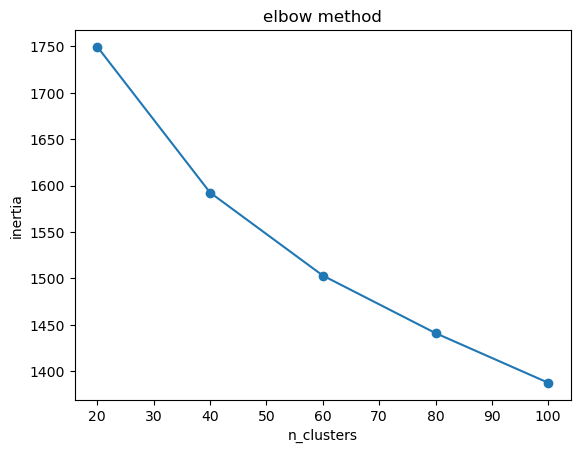

In [17]:
inertias = []
ks = [20, 40, 60, 80, 100]

embeddings_train_norm = normalize(embeddings_train)

for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(embeddings_train_norm)
    inertias.append(km.inertia_)

plt.plot(ks, inertias, marker='o')
plt.xlabel('n_clusters')
plt.ylabel('inertia')
plt.title('elbow method')
plt.show()

In [18]:
N_CLUSTERS = 60

#embeddings_train_norm = normalize(embeddings_train)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
kmeans.fit(embeddings_train_norm)

complaint_to_cluster = dict(zip(all_complaints_train, kmeans.labels_))
print(f"Clusters treinados: {N_CLUSTERS}")

Clusters treinados: 60


In [19]:
print("\nTop queixas por cluster:")
complaints_series = pd.Series(all_complaints_train)

for cluster_id in sorted(set(kmeans.labels_)):
    top = (
        complaints_series[kmeans.labels_ == cluster_id]
        .value_counts()
        .head(10)
        .index.tolist()
    )
    cluster_label = f'cluster_{int(cluster_id):02d}'
    print(f"\n{cluster_label}: {', '.join(top)}")


Top queixas por cluster:

cluster_00: abscess, peritonsillar abscess, groin cyst, abcess, abscesses, abscess on abdomen, abscess left axilla, ovarian cyst vs mass, tonsillar abcess, recurring abscess

cluster_01: status post fall, status post assault, status post mechanical fall, head injury status post fall, status post bike accident, status post fall skull fracture, headache status post assault, status post bicyclist struck, status post passing out, status post fall left rib pain

cluster_02: ingested antifreeze, bicyclist, allergic rxn, anticipated allergic reaction, rabies vaccine, requesting rabies vaccination, palpatations, blood and body fluid exposure, rabies vaccination, facial redness rule out allergic rxn

cluster_03: arm numbness resolved, numbness, left arm numbness, left numbness, left sided numbness, left sided numbness x 48hrs, b hand numbness, facial numbness, left facial numbness, right facial numbness

cluster_04: atrial fibrillation/left shoulder pain, presyncope, 

In [20]:
cluster_counts = (
    pd.Series(kmeans.labels_)
    .value_counts()
    .sort_index()
)

print(cluster_counts.to_string())
print(f"\nTotal complaints no treino: {cluster_counts.sum()}")
print(f"Media por cluster: {cluster_counts.mean():.0f}")
print(f"Menor cluster: {cluster_counts.min()} (cluster_{cluster_counts.idxmin():02d})")
print(f"Maior cluster: {cluster_counts.max()} (cluster_{cluster_counts.idxmax():02d})")

0     177
1     205
2     315
3     252
4     280
5     114
6     205
7     169
8     336
9     200
10    165
11    363
12    151
13    152
14    266
15    239
16    166
17    263
18    220
19    294
20    168
21    144
22    154
23    260
24    286
25    522
26    254
27    179
28    165
29    181
30    115
31    140
32    209
33    111
34    150
35    263
36    203
37    181
38    159
39    140
40    166
41    175
42    136
43    119
44    206
45    165
46    151
47    269
48    222
49    225
50    122
51    106
52    138
53    169
54    330
55    141
56    165
57    216
58    266
59    224

Total complaints no treino: 12227
Media por cluster: 204
Menor cluster: 106 (cluster_51)
Maior cluster: 522 (cluster_25)


In [21]:
CLUSTERS_NOISE = [2, 17, 34]
CLUSTER_UNKNOWN = 60  # ou pode usar 60 se preferir inteiro positivo

def apply_noise_mask(cluster_series, noise_clusters=CLUSTERS_NOISE, unknown_id=CLUSTER_UNKNOWN):
    return cluster_series.replace(noise_clusters, unknown_id)

cluster_train = apply_noise_mask(cluster_train)
cluster_val   = apply_noise_mask(cluster_val)
cluster_test  = apply_noise_mask(cluster_test)

print("Distribuição após mask:")
print(cluster_train.value_counts().sort_index())


Distribuição após mask:
chiefcomplaint_clean
0.0      2591
1.0      2142
3.0      9910
4.0      3345
5.0      2791
6.0     64421
7.0      5447
8.0     14218
9.0      7453
10.0      695
11.0    10553
12.0      886
13.0    10423
14.0     1423
15.0    19685
16.0     3476
18.0     1883
19.0     6360
20.0     8600
21.0     1529
22.0      679
23.0      869
24.0    20048
25.0     1350
26.0     1130
27.0     5072
28.0      680
29.0     1784
30.0     1546
31.0     3429
32.0      801
33.0      375
35.0     1791
36.0     2735
37.0     1067
38.0     8266
39.0     8168
60.0    20927
Name: count, dtype: int64


In [22]:
df.columns

Index(['stay_id', 'subject_id', 'intime', 'is_female', 'race_grouped',
       'arrival_transport', 'hour_of_day', 'is_daytime', 'temperature',
       'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity',
       'chiefcomplaint', 'anchor_age', 'pain_category', 'hypoxia',
       'tachycardia', 'hypotension', 'tachypnea', 'fever',
       'chiefcomplaint_clean', 'chiefcomplaint_norm', 'complaints_list',
       'complaint_clusters_list', 'complaint_cluster_00',
       'complaint_cluster_01', 'complaint_cluster_02', 'complaint_cluster_03',
       'complaint_cluster_04', 'complaint_cluster_05', 'complaint_cluster_06',
       'complaint_cluster_07', 'complaint_cluster_08', 'complaint_cluster_09',
       'complaint_cluster_10', 'complaint_cluster_11', 'complaint_cluster_12',
       'complaint_cluster_13', 'complaint_cluster_14', 'complaint_cluster_15',
       'complaint_cluster_16', 'complaint_cluster_17', 'complaint_cluster_18',
       'complaint_cluster_19', 'complaint_cluster_20'

In [23]:
def get_cluster_flags(
    complaints_series_norm,
    target_index,
    embedding_model,
    kmeans,
    embedding_cache,
    embedding_batch_size=EMBEDDING_BATCH_SIZE,
    noise_clusters=CLUSTERS_NOISE,
    unknown_id=60,
    mlb=None,
):
    # 1) Reuse cache and encode only unseen complaints.
    unique_complaints = pd.Series(complaints_series_norm).dropna().unique().tolist()
    missing_complaints = [c for c in unique_complaints if c not in embedding_cache]
    if missing_complaints:
        new_embeddings = embedding_model.encode(
            missing_complaints,
            batch_size=embedding_batch_size,
            show_progress_bar=False,
            convert_to_numpy=True,
        )
        new_embeddings = normalize(new_embeddings)
        embedding_cache.update(dict(zip(missing_complaints, new_embeddings)))

    # 2) Predict cluster per complaint and map noisy clusters to unknown.
    if unique_complaints:
        embeddings_for_predict = np.vstack([embedding_cache[c] for c in unique_complaints])
        embeddings_for_predict = normalize(embeddings_for_predict)
        predicted_clusters = kmeans.predict(embeddings_for_predict).astype(int)
        noise_set = set(noise_clusters)
        complaint_to_cluster = {
            complaint: (unknown_id if int(cluster_id) in noise_set else int(cluster_id))
            for complaint, cluster_id in zip(unique_complaints, predicted_clusters)
        }
    else:
        complaint_to_cluster = {}

    # 3) Aggregate multilabel clusters by index (stay_id) and binarize with fixed classes [0..60].
    per_complaint_cluster = pd.Series(complaints_series_norm).map(complaint_to_cluster).dropna().astype(int)
    grouped_clusters = per_complaint_cluster.groupby(level=0).apply(lambda values: sorted(set(values.tolist())))

    if mlb is None:
        mlb = MultiLabelBinarizer(classes=list(range(unknown_id + 1)))
        mlb.fit([[]])

    target_index = pd.Index(target_index)
    grouped_clusters = grouped_clusters.reindex(target_index)
    cluster_lists = [clusters if isinstance(clusters, list) else [] for clusters in grouped_clusters.tolist()]
    flags_array = mlb.transform(cluster_lists)

    bert_cols = [f"complaint_cluster_bert_{i:02d}" for i in range(unknown_id)] + ["complaint_cluster_bert_unknown"]
    flags_df = pd.DataFrame(flags_array, index=target_index, columns=bert_cols).astype(int)
    return flags_df, mlb


flags_train, mlb_bert = get_cluster_flags(
    complaints_train_norm,
    X_train_4.index,
    embedding_model,
    kmeans,
    embedding_cache,
    noise_clusters=CLUSTERS_NOISE,
    unknown_id=60,
    mlb=None,
 )
flags_val, _ = get_cluster_flags(
    complaints_val_norm,
    X_val_4.index,
    embedding_model,
    kmeans,
    embedding_cache,
    noise_clusters=CLUSTERS_NOISE,
    unknown_id=60,
    mlb=mlb_bert,
 )
flags_test, _ = get_cluster_flags(
    complaints_test_norm,
    X_test_4.index,
    embedding_model,
    kmeans,
    embedding_cache,
    noise_clusters=CLUSTERS_NOISE,
    unknown_id=60,
    mlb=mlb_bert,
 )

# Idempotent rerun: drop only old BERT flags and keep MiniLM columns untouched.
bert_cols_existing_train = [c for c in X_train_4.columns if c.startswith("complaint_cluster_bert_")]
bert_cols_existing_val = [c for c in X_val_4.columns if c.startswith("complaint_cluster_bert_")]
bert_cols_existing_test = [c for c in X_test_4.columns if c.startswith("complaint_cluster_bert_")]

if bert_cols_existing_train:
    X_train_4 = X_train_4.drop(columns=bert_cols_existing_train)
if bert_cols_existing_val:
    X_val_4 = X_val_4.drop(columns=bert_cols_existing_val)
if bert_cols_existing_test:
    X_test_4 = X_test_4.drop(columns=bert_cols_existing_test)

X_train_4 = X_train_4.join(flags_train)
X_val_4 = X_val_4.join(flags_val)
X_test_4 = X_test_4.join(flags_test)

artifact_dir = "/home/jovyan/work/06_Output/artifacts"
os.makedirs(artifact_dir, exist_ok=True)
mlb_bert_path = os.path.join(artifact_dir, "mlb_bert.pkl")
joblib.dump(mlb_bert, mlb_bert_path)

minilm_cols_train = [c for c in X_train_4.columns if re.fullmatch(r"complaint_cluster_\d{2}", c)]
bert_cols_train = [c for c in X_train_4.columns if c.startswith("complaint_cluster_bert_")]
bert_distribution_train = flags_train.sum(axis=0).sort_values(ascending=False)

print(f"Final X_train_4 shape: {X_train_4.shape}")
print(f"MiniLM columns in train: {len(minilm_cols_train)}")
print(f"BERT columns in train: {len(bert_cols_train)}")
print(f"Saved mlb_bert to: {mlb_bert_path}")
print("BERT flag distribution in train (patients per cluster):")
print(bert_distribution_train.to_string())

Final X_train_4 shape: (258559, 130)
MiniLM columns in train: 40
BERT columns in train: 61
Saved mlb_bert to: /home/jovyan/work/06_Output/artifacts/mlb_bert.pkl
BERT flag distribution in train (patients per cluster):
complaint_cluster_bert_57         26844
complaint_cluster_bert_54         16444
complaint_cluster_bert_unknown    14550
complaint_cluster_bert_49         11708
complaint_cluster_bert_01          6933
complaint_cluster_bert_47          6469
complaint_cluster_bert_23          6092
complaint_cluster_bert_45          5923
complaint_cluster_bert_10          5734
complaint_cluster_bert_26          5668
complaint_cluster_bert_46          5374
complaint_cluster_bert_11          4447
complaint_cluster_bert_29          4169
complaint_cluster_bert_42          3747
complaint_cluster_bert_58          3688
complaint_cluster_bert_18          3515
complaint_cluster_bert_39          3009
complaint_cluster_bert_59          3007
complaint_cluster_bert_37          2754
complaint_cluster_bert_

In [24]:
# MiniLM
mini_names = {
    0:  "urologic_uti_kidney",
    1:  "bilateral_limb_pain_swelling",
    2:  "upper_extremity_shoulder_pain",
    3:  "sore_throat_cough_ent",
    4:  "allergic_reaction_bite_rash",
    5:  "hand_finger_laceration_injury",
    6:  "syncope_seizure_arrhythmia",
    7:  "shortness_of_breath",
    8:  "trauma_laceration_assault",
    9:  "flank_quadrant_abdominal_pain",
    10: "psychiatric_substance_overdose",
    11: "weakness_functional_decline",
    12: "abscess_gi_bleeding_mixed",
    13: "ear_pain_ent",
    14: "psychiatric_altered_fatigue",
    15: "foot_ankle_toe_injury",
    16: "fracture_orthopedic",
    17: "eval_request",
    18: "eye_vision",
    19: "dizziness_vertigo",
    20: "swelling_facial_neck",
    21: "device_tube_drain",
    22: "fever_viral_illness",
    23: "bleeding_vaginal_rectal",
    24: "motor_vehicle_collision",
    25: "headache_neck_facial_pain",
    26: "abdominal_pain_gi",
    27: "miscellaneous_administrative",
    28: "leg_ankle_hip_pain",
    29: "laceration_head_face_extremity",
    30: "nausea_vomiting",
    31: "status_post_event",
    32: "rule_out_diagnosis_neuro",
    33: "back_dental_rectal_pain",
    34: "numbness_tingling",
    35: "chest_pain",
    36: "hemodynamic_metabolic",
    37: "mass_lesion",
    38: "miscellaneous_rare",
    39: "cellulitis_cyst",
}

# BioClinicalBERT
bert_names = {
    0:  "abscess_cyst",
    1:  "status_post_fall_trauma",
    2:  "miscellaneous_rare",
    3:  "numbness_extremity",
    4:  "syncope_epistaxis_mixed",
    5:  "motor_vehicle_collision",
    6:  "wound_postop_bleeding",
    7:  "hemorrhage_vascular",
    8:  "abdominal_pain_distension",
    9:  "facial_eye_swelling_droop",
    10: "shortness_of_breath",
    11: "eval_request",
    12: "hand_finger_infection_injury",
    13: "cellulitis_skin_infection",
    14: "erythema_edema_swelling",
    15: "spinal_fracture",
    16: "foreign_body_burn_bleeding",
    17: "miscellaneous_abnormal_finding",
    18: "quadrant_abdominal_extremity_pain",
    19: "bilateral_pain_swelling",
    20: "device_tube_obstruction",
    21: "hemodynamic_instability",
    22: "fever_viral_illness",
    23: "nausea_vomiting",
    24: "incidental_finding_od",
    25: "flank_back_shoulder_pain",
    26: "dental_urologic_syncope",
    27: "finger_ankle_minor_injury",
    28: "overdose_bite_exposure",
    29: "neuro_psychiatric_altered",
    30: "rectal_bleeding_drain",
    31: "postop_pain_complication",
    32: "dysphagia_bleeding_respiratory",
    33: "functional_decline_voiding",
    34: "generic_single_word",
    35: "administrative_low_acuity",
    36: "abnormal_labs_vitals",
    37: "swelling_rash_oral",
    38: "rule_out_diagnosis",
    39: "nonspecific_systemic",
    40: "foreign_body_fracture_dvt",
    41: "laceration_anatomic",
    42: "trauma_assault_injury",
    43: "tachycardia_cardiac_arrhythmia",
    44: "gi_surgical_acute",
    45: "headache_ent_vertigo",
    46: "urologic_gi_bleeding",
    47: "psychiatric_substance",
    48: "rash_erythema_jaundice",
    49: "chest_pain",
    50: "laceration_face_extremity",
    51: "mass_lesion_lymph",
    52: "catheter_dialysis_urologic",
    53: "status_post_event",
    54: "localized_pain_extremity",
    55: "pedestrian_cyclist_struck",
    56: "altered_mental_status_neuro",
    57: "pain_nonspecific_multisite",
    58: "dizziness_headache_mixed",
    59: "orthopedic_dislocation_injury",
}

# Build unified rename map.
rename_map = {}

for i, name in mini_names.items():
    rename_map[f"complaint_cluster_{i:02d}"] = f"m_{name}"

for i, name in bert_names.items():
    rename_map[f"complaint_cluster_bert_{i:02d}"] = f"b_{name}"

rename_map["complaint_cluster_bert_unknown"] = "b_unknown_noise"

# Apply to all splits.
X_train_4 = X_train_4.rename(columns=rename_map)
X_val_4 = X_val_4.rename(columns=rename_map)
X_test_4 = X_test_4.rename(columns=rename_map)

# Confirm resulting feature groups.
mini_cols = [c for c in X_train_4.columns if c.startswith("m_")]
bert_cols = [c for c in X_train_4.columns if c.startswith("b_")]
print(f"MiniLM columns: {len(mini_cols)}")
print(f"BERT columns:   {len(bert_cols)}")
print(f"Final shape:    {X_train_4.shape}")

MiniLM columns: 40
BERT columns:   61
Final shape:    (258559, 130)


In [1]:
df['complaints_list'] = df['chiefcomplaint_clean'].str.split(r',\s*')
df['complaints_list'] = df['complaints_list'].apply(
    lambda complaints: [
        normalize_complaint(c.strip())
        for c in complaints
        if isinstance(c, str) and c.strip()
    ]
    if isinstance(complaints, list)
    else [],
)

# Keep MiniLM cluster features limited to the defined MiniLM cluster names (0..39).
valid_minilm_clusters = set(cluster_names.keys())

df['complaint_clusters_list'] = df['complaints_list'].apply(
    lambda complaints: sorted(
        {
            complaint_to_cluster[c.strip()]
            for c in complaints
            if isinstance(c, str)
            and c.strip() in complaint_to_cluster
            and complaint_to_cluster[c.strip()] in valid_minilm_clusters
        }
    )
    if isinstance(complaints, list)
    else [],
)

minilm_classes = sorted(valid_minilm_clusters)
mlb = MultiLabelBinarizer(classes=minilm_classes)
cluster_dummies = mlb.fit_transform(df['complaint_clusters_list'])
cluster_df = pd.DataFrame(
    cluster_dummies,
    columns=[f"m_{mini_names[i]}" for i in minilm_classes],
    index=df.index,
)

# Idempotent rerun: replace only MiniLM cluster columns.
existing_minilm_cols = [c for c in df.columns if re.fullmatch(r"complaint_cluster_\d{2}", c)]
if existing_minilm_cols:
    df = df.drop(columns=existing_minilm_cols)

df = pd.concat([df, cluster_df], axis=1)
print(f"MiniLM cluster columns added: {cluster_df.shape[1]}")

NameError: name 'df' is not defined

In [32]:
if 'cluster_df' not in globals():
    raise NameError("cluster_df is not defined. Run the previous MiniLM cluster feature cell first.")

mask = df['complaint_clusters_list'].apply(len) > 1
preview_cols = ['chiefcomplaint_clean'] + list(cluster_df.columns[:8])

print("\nExample rows with multiple complaints:")
print(df.loc[mask, preview_cols].head(3))
print(f"\nShape after cluster enrichment: {df.shape}")


Example rows with multiple complaints:
                           chiefcomplaint_clean  complaint_cluster_00  \
28                 weakness, ruq abdominal pain                     0   
58  abnormal labs, hypertension, visual changes                     0   
60                          s/p fall, bicyclist                     0   

    complaint_cluster_01  complaint_cluster_02  complaint_cluster_03  \
28                     0                     0                     0   
58                     0                     0                     0   
60                     1                     1                     0   

    complaint_cluster_04  complaint_cluster_05  complaint_cluster_06  \
28                     0                     0                     0   
58                     0                     0                     0   
60                     0                     0                     0   

    complaint_cluster_07  
28                     0  
58                     0  
60      

In [ ]:
df.columns

Index(['stay_id', 'subject_id', 'intime', 'is_female', 'race_grouped',
       'arrival_transport', 'hour_of_day', 'is_daytime', 'temperature',
       'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity',
       'chiefcomplaint', 'anchor_age', 'pain_category', 'hypoxia',
       'tachycardia', 'hypotension', 'tachypnea', 'fever',
       'chiefcomplaint_clean', 'chiefcomplaint_norm', 'complaints_list',
       'complaint_clusters_list', 'hour_sin', 'hour_cos', 'acuity_grouped',
       'complaint_cluster_00', 'complaint_cluster_01', 'complaint_cluster_02',
       'complaint_cluster_03', 'complaint_cluster_04', 'complaint_cluster_05',
       'complaint_cluster_06', 'complaint_cluster_07', 'complaint_cluster_08',
       'complaint_cluster_09', 'complaint_cluster_10', 'complaint_cluster_11',
       'complaint_cluster_12', 'complaint_cluster_13', 'complaint_cluster_14',
       'complaint_cluster_15', 'complaint_cluster_16', 'complaint_cluster_17',
       'complaint_cluster_18', 'com

: 

In [35]:
import seaborn as sns

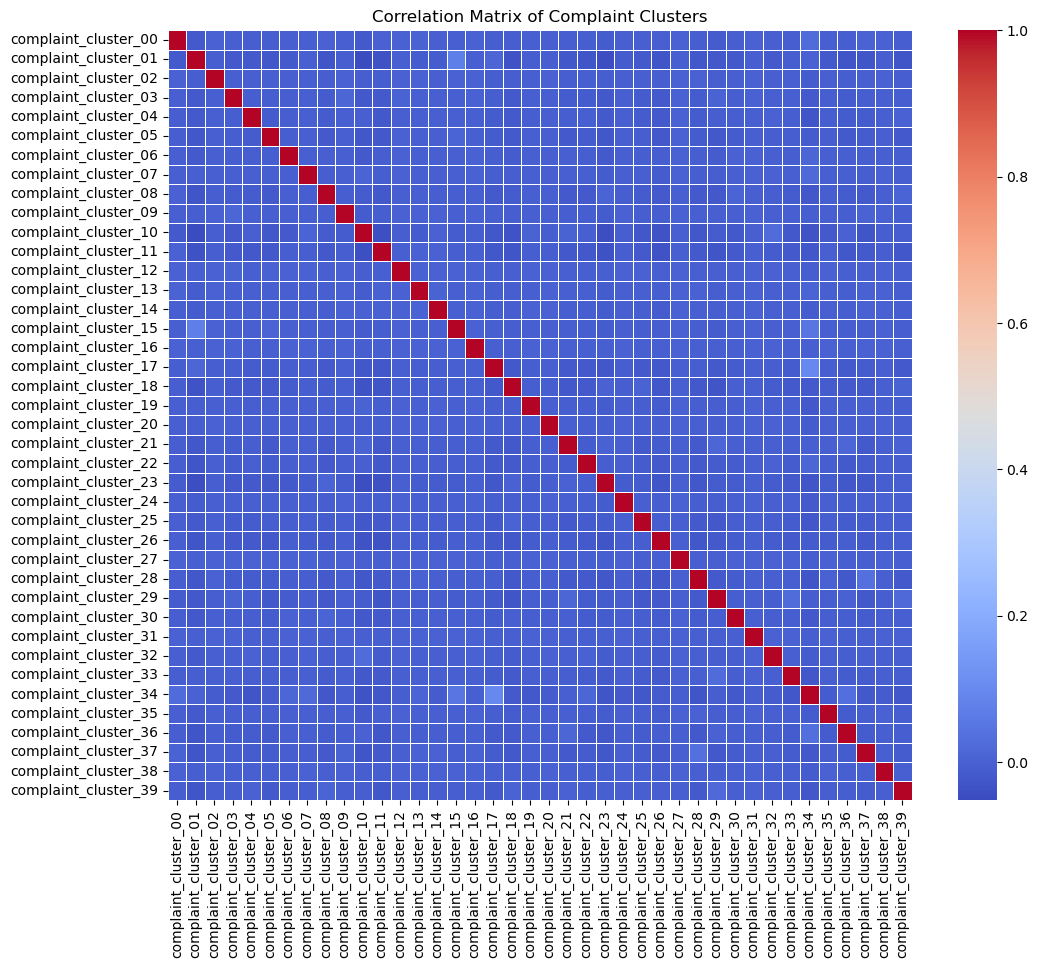

In [36]:
#correlation matrix for nlp clusters
cluster_cols = [col for col in df.columns if col.startswith("complaint_cluster_")]
correlation_matrix = df[cluster_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Complaint Clusters")
plt.show()

## 5. Feature Engineering

In [ ]:
# fourier series decomposition for time features (hour_of_day)

def add_time_features(df):
    df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    return df   
df = add_time_features(df)
print(f"Shape apos adicao de features de tempo: {df.shape}")

Shape apos adicao de features de tempo: (369412, 70)


In [ ]:
#save as pickle for faster reload during experimentation
df.to_pickle("triage_edstay_enriched.pkl")

## 6. XGBoost (5 Classes)

In [ ]:
X_5, y_5 = build_feature_matrix(df, target_col='acuity')
y_5 = y_5 - 1

X_train_5, X_val_5, X_test_5, y_train_5, y_val_5, y_test_5, train_idx_5, val_idx_5, test_idx_5 = split_train_val_test_by_subject(
    X_5,
    y_5,
    groups=df['subject_id'],
)
sample_weights_5 = compute_sample_weights(y_train_5)

print(f"Total features (5 classes): {X_5.shape[1]}")
print(f"Train (5 classes): {X_train_5.shape[0]} observacoes")
print(f"Validation (5 classes): {X_val_5.shape[0]} observacoes")
print(f"Test (5 classes): {X_test_5.shape[0]} observacoes")

Total features (5 classes): 69
Train (5 classes): 258559 observacoes
Validation (5 classes): 36381 observacoes
Test (5 classes): 74472 observacoes


In [ ]:
# Duplicate persistence step removed to avoid repeated writes.

In [ ]:
XGB_PARAMS_5 = {
    'n_estimators': 10000,
    'max_depth': 6,
    'learning_rate': 0.05,
    'objective': 'multi:softmax',
    'num_class': len(ACUITY_LABELS_5),
    'eval_metric': 'mlogloss',
    'random_state': SEED,
    'n_jobs': -1,
}

xgb_model_5c = xgb.XGBClassifier(**XGB_PARAMS_5)
xgb_model_5c.fit(
    X_train_5,
    y_train_5,
    sample_weight=sample_weights_5,
    eval_set=[(X_val_5, y_val_5)],
    callbacks=build_xgb_callbacks(),
    verbose=False,
)

y_pred_5c = xgb_model_5c.predict(X_test_5)

NameError: name 'X_train_5' is not defined

Quadratic Weighted Kappa (5 classes): 0.5300
              precision    recall  f1-score   support

    acuity_1       0.39      0.54      0.45      2337
    acuity_2       0.60      0.67      0.63     24680
    acuity_3       0.76      0.56      0.65     41840
    acuity_4       0.30      0.71      0.42      5423
    acuity_5       0.11      0.07      0.08       192

    accuracy                           0.61     74472
   macro avg       0.43      0.51      0.45     74472
weighted avg       0.66      0.61      0.62     74472



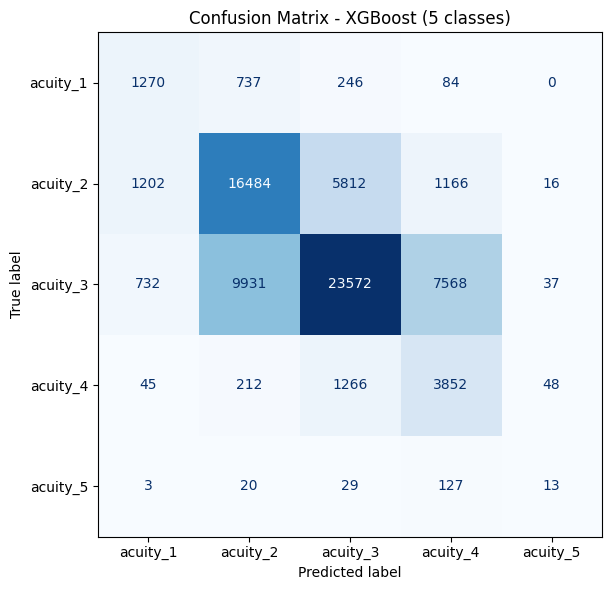

In [ ]:
qwk_5 = cohen_kappa_score(y_test_5, y_pred_5c, weights='quadratic')
print(f"Quadratic Weighted Kappa (5 classes): {qwk_5:.4f}")
print(
    classification_report(
        y_test_5,
        y_pred_5c,
        labels=[0, 1, 2, 3, 4],
        target_names=ACUITY_LABELS_5,
        zero_division=0,
    )
)

cm_5 = confusion_matrix(y_test_5, y_pred_5c, labels=[0, 1, 2, 3, 4])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_5, display_labels=ACUITY_LABELS_5)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - XGBoost (5 classes)')
plt.tight_layout()
plt.show()

## 7. XGBoost (4 Classes)

[0]	validation_0-mlogloss:1.35391
[50]	validation_0-mlogloss:1.02924
[100]	validation_0-mlogloss:0.98163
[150]	validation_0-mlogloss:0.96137
[200]	validation_0-mlogloss:0.95035
[250]	validation_0-mlogloss:0.94279
[300]	validation_0-mlogloss:0.93743
[350]	validation_0-mlogloss:0.93294
[400]	validation_0-mlogloss:0.92895
[450]	validation_0-mlogloss:0.92513
[500]	validation_0-mlogloss:0.92117
[550]	validation_0-mlogloss:0.91754
[600]	validation_0-mlogloss:0.91414
[650]	validation_0-mlogloss:0.91083
[700]	validation_0-mlogloss:0.90780
[750]	validation_0-mlogloss:0.90448
[800]	validation_0-mlogloss:0.90175
[850]	validation_0-mlogloss:0.89858
[900]	validation_0-mlogloss:0.89645
[950]	validation_0-mlogloss:0.89409
[1000]	validation_0-mlogloss:0.89220
[1050]	validation_0-mlogloss:0.89020
[1100]	validation_0-mlogloss:0.88798
[1150]	validation_0-mlogloss:0.88580
[1200]	validation_0-mlogloss:0.88381
[1250]	validation_0-mlogloss:0.88168
[1300]	validation_0-mlogloss:0.88025
[1350]	validation_0-mlog

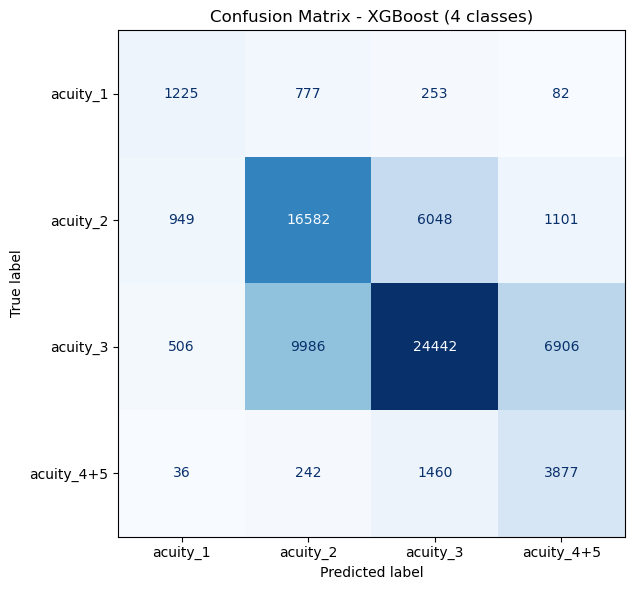

In [ ]:
XGB_PARAMS_4 = {
    'n_estimators': 8000,
    'max_depth': 6,
    'learning_rate': 0.1,
    'objective': 'multi:softmax',
    'num_class': len(ACUITY_LABELS_4),
    'eval_metric': 'mlogloss',
    'random_state': SEED,
    'n_jobs': -1,
    'callbacks': build_xgb_callbacks(),
}

with mlflow.start_run(run_name="xgb_4classes"):

    mlflow.log_params({k: v for k, v in XGB_PARAMS_4.items() if k != 'callbacks'})

    xgb_model_4c = xgb.XGBClassifier(**XGB_PARAMS_4)
    xgb_model_4c.fit(
        X_train_4,
        y_train_4,
        sample_weight=sample_weights_4,
        eval_set=[(X_val_4, y_val_4)],
        verbose=False,
    )

    y_pred_4c = xgb_model_4c.predict(X_test_4)
    qwk_4 = cohen_kappa_score(y_test_4, y_pred_4c, weights='quadratic')
    baseline_cost_4 = -clinical_cost_score(y_test_4.values, y_pred_4c.astype(int))

    mlflow.log_metric("qwk", qwk_4)
    mlflow.log_metric("clinical_cost", baseline_cost_4)

    print(f"Quadratic Weighted Kappa (4 classes): {qwk_4:.4f}")
    print(f"Custo clinico medio (4 classes): {baseline_cost_4:.4f}")
    print(
        classification_report(
            y_test_4,
            y_pred_4c,
            labels=[0, 1, 2, 3],
            target_names=ACUITY_LABELS_4,
            zero_division=0,
        )
    )

    cm_4 = confusion_matrix(y_test_4, y_pred_4c, labels=[0, 1, 2, 3])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_4, display_labels=ACUITY_LABELS_4)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Confusion Matrix - XGBoost (4 classes)')
    plt.tight_layout()
    plt.show()

## 8. LightGBM Benchmark

In [ ]:
LGB_PARAMS_4 = {
    'n_estimators': 9000,
    'max_depth': 6,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'objective': 'multiclass',
    'num_class': len(ACUITY_LABELS_4),
    'class_weight': 'balanced',
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
}

with mlflow.start_run(run_name="lgb_4classes"):

    mlflow.log_params(LGB_PARAMS_4)

    lgb_model = lgb.LGBMClassifier(**LGB_PARAMS_4)
    lgb_model.fit(
        X_train_4,
        y_train_4,
        eval_set=[(X_val_4, y_val_4)],
        callbacks=build_lgb_callbacks(use_lr_scheduler=True),
    )

    y_pred_lgb = lgb_model.predict(X_test_4).astype(int)
    qwk_lgb = cohen_kappa_score(y_test_4, y_pred_lgb, weights='quadratic')
    cost_lgb = -clinical_cost_score(y_test_4.values, y_pred_lgb)

    mlflow.log_metric("qwk", qwk_lgb)
    mlflow.log_metric("clinical_cost", cost_lgb)

    print(f"QWK (LightGBM): {qwk_lgb:.4f}")
    print(f"Custo clinico (LightGBM): {cost_lgb:.4f}")
    print(
        classification_report(
            y_test_4,
            y_pred_lgb,
            labels=[0, 1, 2, 3],
            target_names=ACUITY_LABELS_4,
            zero_division=0,
        )
    )

Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 1.00264
[200]	valid_0's multi_logloss: 0.963188
[300]	valid_0's multi_logloss: 0.948056
[400]	valid_0's multi_logloss: 0.93877
[500]	valid_0's multi_logloss: 0.932267
[600]	valid_0's multi_logloss: 0.926778
[700]	valid_0's multi_logloss: 0.921224
[800]	valid_0's multi_logloss: 0.916371
[900]	valid_0's multi_logloss: 0.912024
[1000]	valid_0's multi_logloss: 0.907161
[1100]	valid_0's multi_logloss: 0.905698
[1200]	valid_0's multi_logloss: 0.904269
[1300]	valid_0's multi_logloss: 0.902968
[1400]	valid_0's multi_logloss: 0.90175
[1500]	valid_0's multi_logloss: 0.900338
[1600]	valid_0's multi_logloss: 0.899039
[1700]	valid_0's multi_logloss: 0.897564
[1800]	valid_0's multi_logloss: 0.896333
[1900]	valid_0's multi_logloss: 0.895137
[2000]	valid_0's multi_logloss: 0.893838
[2100]	valid_0's multi_logloss: 0.893258
[2200]	valid_0's multi_logloss: 0.892745
[2300]	valid_0's multi_logloss: 0.892318
[2400]	v

### 8.1 Baseline Summary

In [ ]:
# Build summary metrics with safe fallbacks in case some training/evaluation cells were not rerun.
qwk_5_safe = globals().get('qwk_5', np.nan)
qwk_4_safe = globals().get('qwk_4', np.nan)
baseline_cost_4_safe = globals().get('baseline_cost_4', np.nan)
qwk_lgb_safe = globals().get('qwk_lgb', np.nan)
cost_lgb_safe = globals().get('cost_lgb', np.nan)

# Try to recover missing QWK values if true/pred vectors are available.
if pd.isna(qwk_4_safe) and 'y_test_4' in globals():
    if 'y_pred_4c' not in globals() and 'xgb_model_4c' in globals() and 'X_test_4' in globals():
        y_pred_4c = xgb_model_4c.predict(X_test_4)
    if 'y_pred_4c' in globals():
        qwk_4_safe = cohen_kappa_score(y_test_4, y_pred_4c, weights='quadratic')

if pd.isna(baseline_cost_4_safe) and 'y_test_4' in globals() and 'y_pred_4c' in globals():
    baseline_cost_4_safe = -clinical_cost_score(y_test_4.values, y_pred_4c.astype(int))

# Persist qwk_5 as requested.
qwk_5 = qwk_5_safe

metrics_summary = pd.DataFrame(
    [
        {'model': 'XGBoost_4_classes', 'qwk': qwk_4_safe, 'clinical_cost': baseline_cost_4_safe},
        {
            'model': 'LightGBM_4_classes',
            'qwk': qwk_lgb_safe,
            'clinical_cost': cost_lgb_safe,
        },
    ]
)
metrics_summary

,model,qwk,clinical_cost
0,XGBoost_4_classes,0.535531,0.564467
1,LightGBM_4_classes,0.528199,0.595700


## 9. Optuna Tuning

In [ ]:
def objective(trial):
    params = {
        'n_estimators': 3000,
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective': 'multi:softmax',
        'num_class': len(ACUITY_LABELS_4),
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',
        'random_state': SEED,
        'n_jobs': -1,
        'callbacks': build_xgb_callbacks(include_logging=False),
    }

    pruning_cb = XGBoostPruningCallback(trial, 'validation_0-mlogloss')

    candidate_model = xgb.XGBClassifier(**params)
    candidate_model.fit(
        X_train_4,
        y_train_4,
        sample_weight=sample_weights_4,
        eval_set=[(X_val_4, y_val_4)],
        verbose=False,
    )

    y_pred_candidate = candidate_model.predict(X_val_4)
    return clinical_cost_score(y_val_4.values, y_pred_candidate.astype(int))


def mlflow_callback(study, trial):
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.log_params(trial.params)
        mlflow.log_metric(
            "clinical_cost",
            -trial.value if trial.value is not None else float("nan"),
        )
        mlflow.log_metric("trial_number", trial.number)


with mlflow.start_run(run_name="optuna_xgb_4classes"):

    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.optimize(
        objective,
        n_trials=OPTUNA_N_TRIALS,
        timeout=3600,
        show_progress_bar=True,
        callbacks=[mlflow_callback],
    )

    print(f"Melhor custo clinico (Optuna): {-study.best_value:.4f}")
    print(f"Melhores hiperparametros: {study.best_params}")

    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_clinical_cost", -study.best_value)
    mlflow.log_metric("n_trials", len(study.trials))

    best_params = study.best_params.copy()
    best_params.update({
        'n_estimators': 3000,
        'objective': 'multi:softmax',
        'num_class': len(ACUITY_LABELS_4),
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',
        'random_state': SEED,
        'n_jobs': -1,
        'callbacks': build_xgb_callbacks(include_logging=False),
    })

    xgb_model_4c_optuna = xgb.XGBClassifier(**best_params)
    xgb_model_4c_optuna.fit(
        X_train_4,
        y_train_4,
        sample_weight=sample_weights_4,
        eval_set=[(X_val_4, y_val_4)],
        verbose=False,
    )

    y_pred_4c_optuna = xgb_model_4c_optuna.predict(X_test_4)
    qwk_4_optuna = cohen_kappa_score(y_test_4, y_pred_4c_optuna, weights='quadratic')
    optuna_cost_4 = -clinical_cost_score(y_test_4.values, y_pred_4c_optuna.astype(int))

    mlflow.log_metric("qwk", qwk_4_optuna)
    mlflow.log_metric("clinical_cost", optuna_cost_4)

    print(f"QWK (Optuna): {qwk_4_optuna:.4f}")
    print(f"Custo clinico (Optuna): {optuna_cost_4:.4f}")
    print(
        classification_report(
            y_pred_4c_optuna,
            y_test_4,
            labels=[0, 1, 2, 3],
            target_names=ACUITY_LABELS_4,
            zero_division=0,
        )
    )

  0%|          | 0/30 [00:00<?, ?it/s]

Melhor custo clinico (Optuna): 0.5455
Melhores hiperparametros: {'max_depth': 8, 'learning_rate': 0.12959963010175118, 'min_child_weight': 3, 'subsample': 0.6880798686229167, 'colsample_bytree': 0.7357961861920648, 'gamma': 0.01475947443972117, 'reg_alpha': 0.0005844317258424099, 'reg_lambda': 0.010540796983210416}
QWK (Optuna): 0.5419
Custo clinico (Optuna): 0.5392
              precision    recall  f1-score   support

    acuity_1       0.51      0.58      0.54      2054
    acuity_2       0.67      0.60      0.63     27527
    acuity_3       0.62      0.75      0.68     34773
  acuity_4+5       0.63      0.35      0.45     10118

    accuracy                           0.63     74472
   macro avg       0.61      0.57      0.58     74472
weighted avg       0.64      0.63      0.63     74472



In [ ]:
def objective_lgb(trial):
    params = {
        'n_estimators': 3000,
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective': 'multiclass',
        'num_class': len(ACUITY_LABELS_4),
        'class_weight': 'balanced',
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1,
    }

    candidate_model = lgb.LGBMClassifier(**params)
    candidate_model.fit(
        X_train_4,
        y_train_4,
        eval_set=[(X_val_4, y_val_4)],
        callbacks=build_lgb_callbacks(use_lr_scheduler=False),
    )

    y_pred_candidate = candidate_model.predict(X_val_4).astype(int)
    cost = clinical_cost_score(y_val_4.values, y_pred_candidate)
    qwk = cohen_kappa_score(y_val_4, y_pred_candidate, weights='quadratic')
    trial.set_user_attr("qwk", qwk)
    return cost


def mlflow_callback_lgb(study, trial):
    with mlflow.start_run(run_name=f"lgb_trial_{trial.number}", nested=True):
        mlflow.log_params(trial.params)
        mlflow.log_metric(
            "clinical_cost",
            -trial.value if trial.value is not None else float("nan"),
        )
        mlflow.log_metric("qwk", trial.user_attrs.get("qwk", float("nan")))
        mlflow.log_metric("trial_number", trial.number)


with mlflow.start_run(run_name="optuna_lgb_4classes"):

    study_lgb = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study_lgb.optimize(
        objective_lgb,
        n_trials=OPTUNA_N_TRIALS,
        timeout=3600,
        show_progress_bar=True,
        callbacks=[mlflow_callback_lgb],
    )

    print(f"Melhor custo clinico (Optuna LGB): {-study_lgb.best_value:.4f}")
    print(f"Melhores hiperparametros: {study_lgb.best_params}")

    mlflow.log_params(study_lgb.best_params)
    mlflow.log_metric("best_clinical_cost", -study_lgb.best_value)
    mlflow.log_metric("n_trials", len(study_lgb.trials))

    best_lgb_params = study_lgb.best_params.copy()
    best_lgb_params.update({
        'n_estimators': 10000,
        'objective': 'multiclass',
        'num_class': len(ACUITY_LABELS_4),
        'class_weight': 'balanced',
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1,
    })

    lgb_final = lgb.LGBMClassifier(**best_lgb_params)
    lgb_final.fit(
        X_train_4,
        y_train_4,
        eval_set=[(X_val_4, y_val_4)],
        callbacks=build_lgb_callbacks(use_lr_scheduler=True),
    )

    y_pred_lgb_final = lgb_final.predict(X_test_4).astype(int)
    qwk_lgb_final = cohen_kappa_score(y_test_4, y_pred_lgb_final, weights='quadratic')
    cost_lgb_final = -clinical_cost_score(y_test_4.values, y_pred_lgb_final)

    mlflow.log_metric("qwk", qwk_lgb_final)
    mlflow.log_metric("clinical_cost", cost_lgb_final)

    print(f"QWK (LGB final): {qwk_lgb_final:.4f}")
    print(f"Custo clinico (LGB final): {cost_lgb_final:.4f}")
    print(classification_report(
        y_test_4, y_pred_lgb_final,
        labels=[0, 1, 2, 3],
        target_names=ACUITY_LABELS_4,
        zero_division=0,
    ))

  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.948639
[200]	valid_0's multi_logloss: 0.930055
[300]	valid_0's multi_logloss: 0.91822
[400]	valid_0's multi_logloss: 0.908592
[500]	valid_0's multi_logloss: 0.90063
[600]	valid_0's multi_logloss: 0.894214
[700]	valid_0's multi_logloss: 0.888208
[800]	valid_0's multi_logloss: 0.882715
[900]	valid_0's multi_logloss: 0.87814
[1000]	valid_0's multi_logloss: 0.874196
[1100]	valid_0's multi_logloss: 0.871143
[1200]	valid_0's multi_logloss: 0.867682
[1300]	valid_0's multi_logloss: 0.864929
[1400]	valid_0's multi_logloss: 0.863371
[1500]	valid_0's multi_logloss: 0.861909
[1600]	valid_0's multi_logloss: 0.860716
[1700]	valid_0's multi_logloss: 0.859324
[1800]	valid_0's multi_logloss: 0.858345
[1900]	valid_0's multi_logloss: 0.857347
[2000]	valid_0's multi_logloss: 0.857068
Early stopping, best iteration is:
[1969]	valid_0's multi_logloss: 0.856907
Training until validation scores don't improve for 50 r

In [ ]:
BEST_PARAMS = {
    'max_depth': 8,
    'learning_rate': 0.12959963010175118,
    'min_child_weight': 3,
    'subsample': 0.6880798686229167,
    'colsample_bytree': 0.7357961861920648,
    'gamma': 0.01475947443972117,
    'reg_alpha': 0.0005844317258424799,
    'reg_lambda': 0.010540796983210416,
    'n_estimators': 10000,
    'objective': 'multi:softmax',
    'num_class': len(ACUITY_LABELS_4),
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'random_state': SEED,
    'n_jobs': -1,
    'callbacks': build_xgb_callbacks(),
}

with mlflow.start_run(run_name="xgb_final_best_params"):

    mlflow.log_params({k: v for k, v in BEST_PARAMS.items() if k != 'callbacks'})

    xgb_final = xgb.XGBClassifier(**BEST_PARAMS)
    xgb_final.fit(
        X_train_4,
        y_train_4,
        sample_weight=sample_weights_4,
        eval_set=[(X_val_4, y_val_4)],
        verbose=False,
    )

    y_pred_final = xgb_final.predict(X_test_4)
    qwk_final = cohen_kappa_score(y_test_4, y_pred_final, weights='quadratic')
    cost_final = -clinical_cost_score(y_test_4.values, y_pred_final.astype(int))

    mlflow.log_metric("qwk", qwk_final)
    mlflow.log_metric("clinical_cost", cost_final)

    print(f"QWK (final): {qwk_final:.4f}")
    print(f"Custo clinico (final): {cost_final:.4f}")
    print(classification_report(
        y_test_4, y_pred_final,
        labels=[0, 1, 2, 3],
        target_names=ACUITY_LABELS_4,
        zero_division=0,
    ))

[0]	validation_0-mlogloss:1.34303
[50]	validation_0-mlogloss:0.98349
[100]	validation_0-mlogloss:0.94218
[150]	validation_0-mlogloss:0.92153
[200]	validation_0-mlogloss:0.90733
[250]	validation_0-mlogloss:0.89325
[300]	validation_0-mlogloss:0.88253
[350]	validation_0-mlogloss:0.87251
[400]	validation_0-mlogloss:0.86369
[450]	validation_0-mlogloss:0.85576
[500]	validation_0-mlogloss:0.84865
[550]	validation_0-mlogloss:0.84250
[600]	validation_0-mlogloss:0.83709
[650]	validation_0-mlogloss:0.83310
[700]	validation_0-mlogloss:0.82870
[750]	validation_0-mlogloss:0.82544
[800]	validation_0-mlogloss:0.82241
[850]	validation_0-mlogloss:0.82006
[900]	validation_0-mlogloss:0.81818
[950]	validation_0-mlogloss:0.81650
[1000]	validation_0-mlogloss:0.81567
[1050]	validation_0-mlogloss:0.81474
[1100]	validation_0-mlogloss:0.81377
[1150]	validation_0-mlogloss:0.81342
[1200]	validation_0-mlogloss:0.81356
[1211]	validation_0-mlogloss:0.81351
QWK (final): 0.5419
Custo clinico (final): 0.5392
           

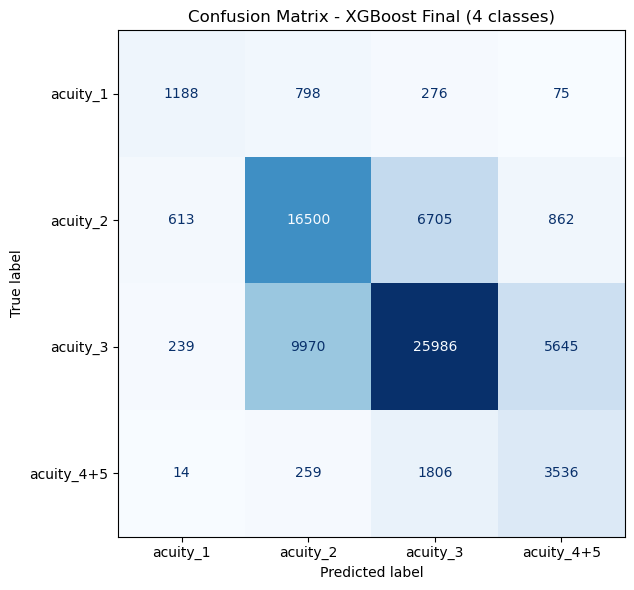

In [ ]:
cm = confusion_matrix(y_test_4, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ACUITY_LABELS_4)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - XGBoost Final (4 classes)')
plt.tight_layout()
plt.show()

## 10. GroupKFold Cross-Validation

In [ ]:
print("XGB best params:", study.best_params)
print("LGB best params:", study_lgb.best_params)

XGB best params: {'max_depth': 8, 'learning_rate': 0.12959963010175118, 'min_child_weight': 3, 'subsample': 0.6880798686229167, 'colsample_bytree': 0.7357961861920648, 'gamma': 0.01475947443972117, 'reg_alpha': 0.0005844317258424099, 'reg_lambda': 0.010540796983210416}
LGB best params: {'max_depth': 7, 'learning_rate': 0.17968351710471944, 'num_leaves': 93, 'min_child_samples': 12, 'subsample': 0.7361609808336007, 'colsample_bytree': 0.7814478639592504, 'reg_alpha': 0.7073220474194105, 'reg_lambda': 0.010352052689919842}


In [ ]:
gkf = GroupKFold(n_splits=KFOLD_SPLITS)
groups_4 = df['subject_id']

xgb_params_kfold = {
    **study.best_params,
    'n_estimators': 3000,
    'objective': 'multi:softmax',
    'num_class': len(ACUITY_LABELS_4),
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'random_state': SEED,
    'n_jobs': -1,
}

lgb_params_kfold = {
    **study_lgb.best_params,
    'n_estimators': 5000,
    'objective': 'multiclass',
    'num_class': len(ACUITY_LABELS_4),
    'class_weight': 'balanced',
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
}

kfold_rows = []

with mlflow.start_run(run_name="kfold_cv_optuna_both"):

    mlflow.log_param("n_splits", KFOLD_SPLITS)
    mlflow.log_param("group_by", "subject_id")
    mlflow.log_param("xgb_source", "optuna_best")
    mlflow.log_param("lgb_source", "optuna_best")
    mlflow.log_param("xgb_n_estimators", 3000)
    mlflow.log_param("lgb_n_estimators", 5000)

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_4, y_4, groups=groups_4), start=1):
        X_train_fold = X_4.iloc[train_idx]
        X_val_fold   = X_4.iloc[val_idx]
        y_train_fold = y_4.iloc[train_idx]
        y_val_fold   = y_4.iloc[val_idx]

        sample_weights_fold = compute_sample_weights(y_train_fold)

        with mlflow.start_run(run_name=f"xgb_fold_{fold}", nested=True):
            xgb_fold_model = xgb.XGBClassifier(
                **xgb_params_kfold,
                callbacks=build_xgb_callbacks(),
            )
            xgb_fold_model.fit(
                X_train_fold, y_train_fold,
                sample_weight=sample_weights_fold,
                eval_set=[(X_val_fold, y_val_fold)],
                verbose=False,
            )
            y_pred_xgb_fold = xgb_fold_model.predict(X_val_fold)
            qwk_xgb = cohen_kappa_score(y_val_fold, y_pred_xgb_fold, weights='quadratic')
            cost_xgb = -clinical_cost_score(y_val_fold.values, y_pred_xgb_fold.astype(int))
            mlflow.log_metric("qwk", qwk_xgb)
            mlflow.log_metric("clinical_cost", cost_xgb)
            mlflow.log_metric("fold", fold)
            kfold_rows.append({'model': 'XGBoost_optuna', 'fold': fold, 'qwk': qwk_xgb, 'clinical_cost': cost_xgb})

        with mlflow.start_run(run_name=f"lgb_fold_{fold}", nested=True):
            lgb_fold_model = lgb.LGBMClassifier(**lgb_params_kfold)
            lgb_fold_model.fit(
                X_train_fold, y_train_fold,
                eval_set=[(X_val_fold, y_val_fold)],
                callbacks=build_lgb_callbacks(use_lr_scheduler=False),
            )
            y_pred_lgb_fold = lgb_fold_model.predict(X_val_fold).astype(int)
            qwk_lgb = cohen_kappa_score(y_val_fold, y_pred_lgb_fold, weights='quadratic')
            cost_lgb = -clinical_cost_score(y_val_fold.values, y_pred_lgb_fold)
            mlflow.log_metric("qwk", qwk_lgb)
            mlflow.log_metric("clinical_cost", cost_lgb)
            mlflow.log_metric("fold", fold)
            kfold_rows.append({'model': 'LightGBM_optuna', 'fold': fold, 'qwk': qwk_lgb, 'clinical_cost': cost_lgb})

    kfold_fold_metrics = pd.DataFrame(kfold_rows).sort_values(['model', 'fold']).reset_index(drop=True)
    kfold_summary_metrics = (
        kfold_fold_metrics.groupby('model')[['qwk', 'clinical_cost']]
        .agg(['mean', 'std'])
        .round(4)
    )

    for model_name, row in kfold_summary_metrics.iterrows():
        mlflow.log_metric(f"{model_name}_qwk_mean", row['qwk']['mean'])
        mlflow.log_metric(f"{model_name}_qwk_std", row['qwk']['std'])
        mlflow.log_metric(f"{model_name}_cost_mean", row['clinical_cost']['mean'])
        mlflow.log_metric(f"{model_name}_cost_std", row['clinical_cost']['std'])

    print('Fold by fold:')
    display(kfold_fold_metrics)
    print('\nSummary (mean and standard deviation):')
    display(kfold_summary_metrics)

[0]	validation_0-mlogloss:1.34352
[50]	validation_0-mlogloss:0.98568
[100]	validation_0-mlogloss:0.94411
[150]	validation_0-mlogloss:0.92490
[200]	validation_0-mlogloss:0.91281
[250]	validation_0-mlogloss:0.90073
[300]	validation_0-mlogloss:0.88961
[350]	validation_0-mlogloss:0.87918
[400]	validation_0-mlogloss:0.87046
[450]	validation_0-mlogloss:0.86312
[500]	validation_0-mlogloss:0.85632
[550]	validation_0-mlogloss:0.85087
[600]	validation_0-mlogloss:0.84522
[650]	validation_0-mlogloss:0.84032
[700]	validation_0-mlogloss:0.83633
[750]	validation_0-mlogloss:0.83295
[800]	validation_0-mlogloss:0.82985
[850]	validation_0-mlogloss:0.82688
[900]	validation_0-mlogloss:0.82415
[950]	validation_0-mlogloss:0.82234
[1000]	validation_0-mlogloss:0.82025
[1050]	validation_0-mlogloss:0.81909
[1100]	validation_0-mlogloss:0.81817
[1150]	validation_0-mlogloss:0.81719
[1200]	validation_0-mlogloss:0.81676
[1250]	validation_0-mlogloss:0.81632
[1300]	validation_0-mlogloss:0.81622
[1346]	validation_0-mlog

,model,fold,qwk,clinical_cost
0,LightGBM_optuna,1,0.533576,0.536077
1,LightGBM_optuna,2,0.538699,0.542872
2,LightGBM_optuna,3,0.533345,0.539888
3,LightGBM_optuna,4,0.532744,0.537330
4,LightGBM_optuna,5,0.531365,0.543394
5,XGBoost_optuna,1,0.541288,0.533384
6,XGBoost_optuna,2,0.544850,0.535834
7,XGBoost_optuna,3,0.542339,0.537465
8,XGBoost_optuna,4,0.540448,0.527138
9,XGBoost_optuna,5,0.536503,0.545329



Summary (mean and standard deviation):


qwk         clinical_cost        
                   mean     std          mean     std
model                                                
LightGBM_optuna  0.5339  0.0028        0.5399  0.0033
XGBoost_optuna   0.5411  0.0030        0.5358  0.0066

In [ ]:
import joblib
import os

# output directory
os.makedirs("06_Output/artifacts", exist_ok=True)

# ── ML models ──────────────────────────────────────────────────────────────
joblib.dump(xgb_final, "06_Output/artifacts/xgb_final.pkl")
joblib.dump(lgb_final, "06_Output/artifacts/lgb_final.pkl")

# ── NLP artifacts ──────────────────────────────────────────────────────────
joblib.dump(kmeans, "06_Output/artifacts/kmeans.pkl")
joblib.dump(complaint_to_cluster, "06_Output/artifacts/complaint_to_cluster.pkl")
joblib.dump(mlb, "06_Output/artifacts/mlb.pkl")

# ── Feature columns (critical for inference alignment) ─────────────────────
joblib.dump(list(X_4.columns), "06_Output/artifacts/feature_columns.pkl")

# ── Sentence transformer ───────────────────────────────────────────────────
embedding_model.save("06_Output/artifacts/embedding_model")

# ── MLflow: log all artifacts in the final run ─────────────────────────────
with mlflow.start_run(run_name="artifacts_final"):

    mlflow.xgboost.log_model(xgb_final, "xgb_final_model")
    mlflow.lightgbm.log_model(lgb_final, "lgb_final_model")

    mlflow.log_artifact("06_Output/artifacts/kmeans.pkl")
    mlflow.log_artifact("06_Output/artifacts/complaint_to_cluster.pkl")
    mlflow.log_artifact("06_Output/artifacts/mlb.pkl")
    mlflow.log_artifact("06_Output/artifacts/feature_columns.pkl")
    mlflow.log_artifact("06_Output/artifacts/embedding_model")

    # log best params for reference
    mlflow.log_params({f"xgb_{k}": v for k, v in study.best_params.items()})
    mlflow.log_params({f"lgb_{k}": v for k, v in study_lgb.best_params.items()})

    mlflow.log_metric("xgb_qwk", qwk_final)
    mlflow.log_metric("xgb_clinical_cost", cost_final)
    mlflow.log_metric("lgb_qwk", qwk_lgb_final)
    mlflow.log_metric("lgb_clinical_cost", cost_lgb_final)

print("Artifacts saved:")
for f in os.listdir("06_Output/artifacts"):
    path = f"06_Output/artifacts/{f}"
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"  {f}: {size_mb:.1f} MB")

## 11. SHAP Explainability

Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes_optuna
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.349130
1,heartrate,0.332413
2,sbp,0.267663
3,dbp,0.184296
4,complaint_cluster_26,0.178057
5,temperature,0.176551
6,arrival_transport_AMBULANCE,0.169597
7,resprate,0.156728
8,complaint_cluster_35,0.151989
9,pain,0.147939


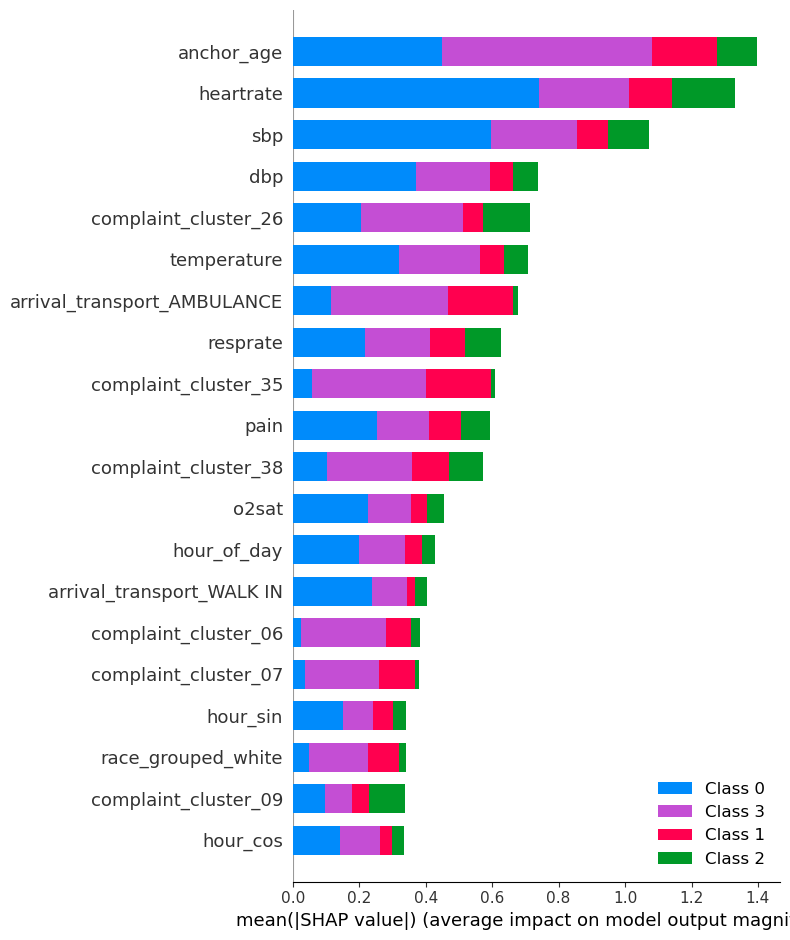

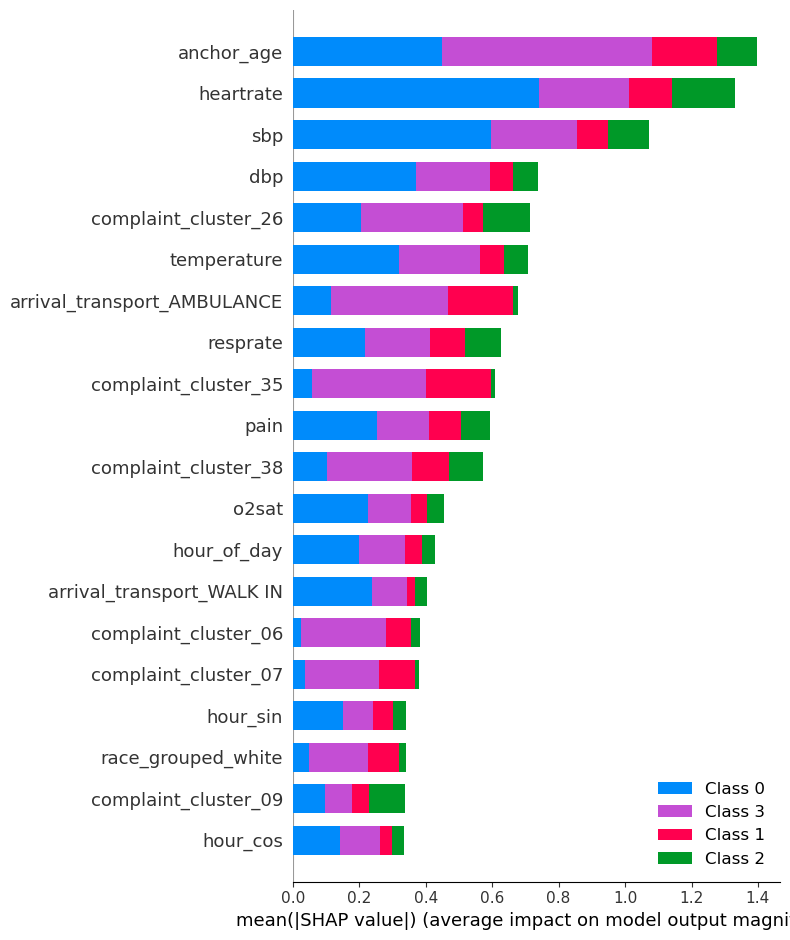


=== SHAP: LightGBM ===


: 

In [ ]:
# SHAP explainability for the 4-class setup: separate outputs for XGBoost and LightGBM,
# followed by a direct comparison table and plot.
if "shap" not in globals():
    raise NameError("Run Section 1 (Imports and Config) to load the shap package before this step.")

if "X_test_4" not in globals() or "y_test_4" not in globals():
    raise ValueError("X_test_4 and y_test_4 are not available. Run Section 7 to prepare the data.")

xgb_model_to_explain = globals().get("xgb_model_4c_optuna") or globals().get("xgb_model_4c")
lgb_model_to_explain = globals().get("lgb_model")

if xgb_model_to_explain is None:
    raise ValueError("XGBoost 4-class model not found. Run Section 7 or 9 before SHAP.")
if lgb_model_to_explain is None:
    # Fallback to alternative LightGBM model names used in this notebook.
    for candidate_name in ("lgb_model_4c_optuna", "lgb_model_4c", "lgb_fold_model"):
        candidate_model = globals().get(candidate_name)
        if candidate_model is not None:
            lgb_model_to_explain = candidate_model
            print(f"Warning: 'lgb_model' not found; using '{candidate_name}' for SHAP.")
            break

    if lgb_model_to_explain is None:
        raise ValueError("LightGBM 4-class model not found. Run Section 8 before SHAP.")

xgb_model_name = (
    "XGBoost_4_classes_optuna"
    if "xgb_model_4c_optuna" in globals() and globals().get("xgb_model_4c_optuna") is not None
    else "XGBoost_4_classes"
)

sample_size = min(SHAP_SAMPLE_SIZE, len(X_test_4))
if sample_size < len(X_test_4):
    X_explain = X_test_4.sample(n=sample_size, random_state=SEED)
else:
    X_explain = X_test_4.copy()

print(f"SHAP sample: {X_explain.shape[0]} rows x {X_explain.shape[1]} features")
print(f"XGBoost model used: {xgb_model_name}")
print("LightGBM model used: LightGBM_4_classes")


def mean_abs_shap_per_feature(shap_values):
    if isinstance(shap_values, list):
        shap_stack = np.stack([np.abs(class_values) for class_values in shap_values], axis=-1)
        return shap_stack.mean(axis=(0, 2))

    shap_array = np.asarray(shap_values)
    if shap_array.ndim == 3:
        return np.abs(shap_array).mean(axis=(0, 2))
    if shap_array.ndim == 2:
        return np.abs(shap_array).mean(axis=0)

    raise ValueError(f"Unexpected SHAP format: {shap_array.shape}")


def shap_values_for_plot(shap_values):
    if isinstance(shap_values, list):
        return shap_values

    shap_array = np.asarray(shap_values)
    if shap_array.ndim == 3:
        return [shap_array[:, :, class_idx] for class_idx in range(shap_array.shape[2])]

    return shap_array


def build_shap_importance(model, X_frame, model_tag):
    explainer = shap.TreeExplainer(model)
    shap_values_raw = explainer.shap_values(X_frame)
    importance_df = (
        pd.DataFrame(
            {
                "feature": X_frame.columns,
                f"mean_abs_shap_{model_tag}": mean_abs_shap_per_feature(shap_values_raw),
            }
        )
        .sort_values(f"mean_abs_shap_{model_tag}", ascending=False)
        .reset_index(drop=True)
    )
    return shap_values_raw, importance_df


# 1) XGBoost SHAP (separate)
print("\n=== SHAP: XGBoost ===")
shap_values_xgb_raw, shap_importance_xgb = build_shap_importance(
    xgb_model_to_explain,
    X_explain,
    "xgb",
)
display(shap_importance_xgb.head(SHAP_MAX_DISPLAY))

shap.summary_plot(
    shap_values_for_plot(shap_values_xgb_raw),
    X_explain,
    plot_type="bar",
    max_display=SHAP_MAX_DISPLAY,
)
shap.summary_plot(
    shap_values_for_plot(shap_values_xgb_raw),
    X_explain,
    max_display=SHAP_MAX_DISPLAY,
)


# 2) LightGBM SHAP (separate)
print("\n=== SHAP: LightGBM ===")
shap_values_lgb_raw, shap_importance_lgb = build_shap_importance(
    lgb_model_to_explain,
    X_explain,
    "lgb",
)
display(shap_importance_lgb.head(SHAP_MAX_DISPLAY))

shap.summary_plot(
    shap_values_for_plot(shap_values_lgb_raw),
    X_explain,
    plot_type="bar",
    max_display=SHAP_MAX_DISPLAY,
)
shap.summary_plot(
    shap_values_for_plot(shap_values_lgb_raw),
    X_explain,
    max_display=SHAP_MAX_DISPLAY,
)


# 3) XGBoost vs LightGBM comparison
print("\n=== XGBoost vs LightGBM comparison ===")
shap_comparison = (
    shap_importance_xgb.merge(shap_importance_lgb, on="feature", how="outer")
    .fillna(0.0)
)

shap_comparison["rank_xgb"] = shap_comparison["mean_abs_shap_xgb"].rank(
    method="dense",
    ascending=False,
).astype(int)
shap_comparison["rank_lgb"] = shap_comparison["mean_abs_shap_lgb"].rank(
    method="dense",
    ascending=False,
).astype(int)
shap_comparison["rank_gap_abs"] = (shap_comparison["rank_xgb"] - shap_comparison["rank_lgb"]).abs()
shap_comparison["importance_gap_abs"] = (
    shap_comparison["mean_abs_shap_xgb"] - shap_comparison["mean_abs_shap_lgb"]
).abs()

shap_comparison = shap_comparison.sort_values(
    "importance_gap_abs",
    ascending=False,
).reset_index(drop=True)

xgb_top_set = set(shap_importance_xgb.head(SHAP_MAX_DISPLAY)["feature"])
lgb_top_set = set(shap_importance_lgb.head(SHAP_MAX_DISPLAY)["feature"])
intersection_count = len(xgb_top_set & lgb_top_set)
union_count = len(xgb_top_set | lgb_top_set)
jaccard_top_features = intersection_count / union_count if union_count else np.nan

print(f"Top-{SHAP_MAX_DISPLAY} overlap: {intersection_count}/{union_count}")
print(f"Top-{SHAP_MAX_DISPLAY} Jaccard: {jaccard_top_features:.4f}")

display(shap_comparison.head(SHAP_MAX_DISPLAY))

plot_compare = (
    shap_comparison.nlargest(SHAP_MAX_DISPLAY, "mean_abs_shap_xgb")
    .sort_values("mean_abs_shap_xgb", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(plot_compare))
ax.barh(y_pos - 0.2, plot_compare["mean_abs_shap_xgb"], height=0.4, label="XGBoost")
ax.barh(y_pos + 0.2, plot_compare["mean_abs_shap_lgb"], height=0.4, label="LightGBM")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_compare["feature"])
ax.set_xlabel("Mean |SHAP|")
ax.set_title("Global SHAP importance: XGBoost vs LightGBM")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Ensemble (XGBoost + LightGBM)

Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para ensemble.
Metodo do ensemble: soft_voting_mean_proba


,model,qwk,clinical_cost
0,XGBoost_4_classes,0.533615,0.579802
1,LightGBM_4_classes,0.555427,0.585106
2,Ensemble_4_classes (soft_voting_mean_proba),0.549611,0.577694



Classification report - Ensemble (4 classes)
              precision    recall  f1-score   support

    acuity_1       0.41      0.65      0.50      2337
    acuity_2       0.62      0.68      0.65     24680
    acuity_3       0.79      0.55      0.65     41840
  acuity_4+5       0.32      0.80      0.45      5615

    accuracy                           0.62     74472
   macro avg       0.53      0.67      0.56     74472
weighted avg       0.68      0.62      0.63     74472



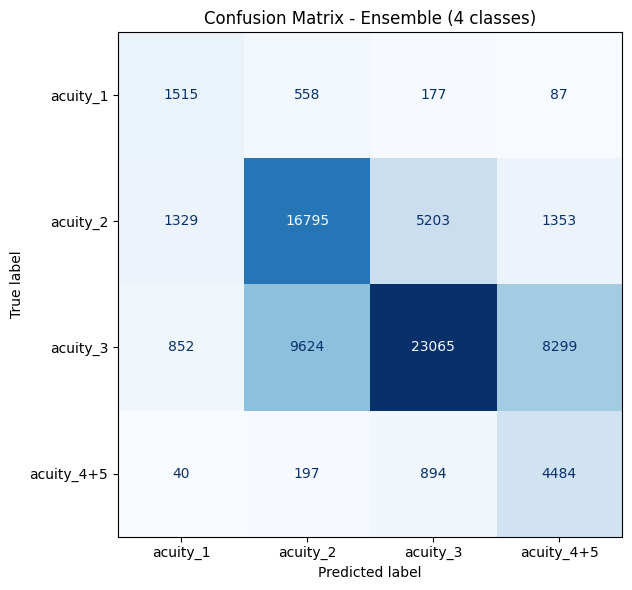

In [ ]:
if "X_test_4" not in globals() or "y_test_4" not in globals():
    raise ValueError("X_test_4 and y_test_4 are not available. Run Section 7 before the ensemble step.")

xgb_ensemble_model = globals().get("xgb_model_4c_optuna") or globals().get("xgb_model_4c")
if xgb_ensemble_model is None:
    raise ValueError("XGBoost 4-class model not found. Run Section 7 or 9 before the ensemble step.")

lgb_ensemble_model = globals().get("lgb_model")
if lgb_ensemble_model is None:
    for candidate_name in ("lgb_model_4c_optuna", "lgb_model_4c", "lgb_fold_model"):
        candidate_model = globals().get(candidate_name)
        if candidate_model is not None:
            lgb_ensemble_model = candidate_model
            print(f"Warning: 'lgb_model' not found; using '{candidate_name}' for ensemble.")
            break

if lgb_ensemble_model is None:
    raise ValueError("LightGBM 4-class model not found. Run Section 8 before the ensemble step.")


def safe_predict_proba(model, X_frame):
    if not hasattr(model, "predict_proba"):
        return None
    try:
        proba = np.asarray(model.predict_proba(X_frame))
        if proba.ndim != 2 or proba.shape[0] != len(X_frame):
            return None
        return proba
    except Exception:
        return None


y_pred_xgb_ens = np.asarray(xgb_ensemble_model.predict(X_test_4)).astype(int)
y_pred_lgb_ens = np.asarray(lgb_ensemble_model.predict(X_test_4)).astype(int)

proba_xgb_ens = safe_predict_proba(xgb_ensemble_model, X_test_4)
proba_lgb_ens = safe_predict_proba(lgb_ensemble_model, X_test_4)

if (
    proba_xgb_ens is not None
    and proba_lgb_ens is not None
    and proba_xgb_ens.shape == proba_lgb_ens.shape
):
    ensemble_method = "soft_voting_mean_proba"
    proba_ensemble_4 = 0.5 * proba_xgb_ens + 0.5 * proba_lgb_ens
    y_pred_ensemble_4 = np.argmax(proba_ensemble_4, axis=1).astype(int)
else:
    ensemble_method = "hard_voting_fallback_xgb_on_tie"
    # For two models, disagreement is a tie; break ties with XGBoost.
    y_pred_ensemble_4 = np.where(y_pred_xgb_ens == y_pred_lgb_ens, y_pred_xgb_ens, y_pred_xgb_ens).astype(int)
    proba_ensemble_4 = None

qwk_xgb_ens = cohen_kappa_score(y_test_4, y_pred_xgb_ens, weights="quadratic")
qwk_lgb_ens = cohen_kappa_score(y_test_4, y_pred_lgb_ens, weights="quadratic")
qwk_ensemble_4 = cohen_kappa_score(y_test_4, y_pred_ensemble_4, weights="quadratic")

cost_xgb_ens = -clinical_cost_score(y_test_4.values, y_pred_xgb_ens.astype(int))
cost_lgb_ens = -clinical_cost_score(y_test_4.values, y_pred_lgb_ens.astype(int))
cost_ensemble_4 = -clinical_cost_score(y_test_4.values, y_pred_ensemble_4.astype(int))

ensemble_summary_4 = pd.DataFrame(
    [
        {"model": "XGBoost_4_classes", "qwk": qwk_xgb_ens, "clinical_cost": cost_xgb_ens},
        {"model": "LightGBM_4_classes", "qwk": qwk_lgb_ens, "clinical_cost": cost_lgb_ens},
        {"model": f"Ensemble_4_classes ({ensemble_method})", "qwk": qwk_ensemble_4, "clinical_cost": cost_ensemble_4},
    ]
)

print(f"Ensemble method: {ensemble_method}")
display(ensemble_summary_4)

print("\nClassification report - Ensemble (4 classes)")
print(
    classification_report(
        y_test_4,
        y_pred_ensemble_4,
        labels=[0, 1, 2, 3],
        target_names=ACUITY_LABELS_4,
        zero_division=0,
    )
)

cm_ensemble_4 = confusion_matrix(y_test_4, y_pred_ensemble_4, labels=[0, 1, 2, 3])
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_ensemble_4, display_labels=ACUITY_LABELS_4).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
)
ax.set_title("Confusion Matrix - Ensemble (4 classes)")
plt.tight_layout()
plt.show()